### TRABAJO PRACTICO FINAL
Alumnos:
- Maria Victoria Teran Beiza
- Fernando Vasconcelos
- Gustavo Uñapillco
- Lara Rosenberg

#### INTRODUCCION
Para el presente trabajo se utilizó un dataset de encuestas de satisfacción de una aerolinea comercial, obtenido de Kaggle: https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction

El mismo contiene la siguiente información:
- id: Identificador del cliente.
- Gender: Género del pasajero (Female= femenino, Male=masculino).
- Customer Type: Tipo de cliente (Loyal customer, disloyal customer).
- Age: Edad del pasajero.
- Type of Travel: Propósito del vuelo para el pasajero (Personal Travel, Business Travel).
- Class: Clase en el vuelo a la que pertenece el pasajero (Business, Eco, Eco Plus).
- Flight distance: Distancia del vuelo.
- Inflight wifi service: Nivel de satisfacción con el servicio de wifi a bordo (0:Not Applicable;1-5).
- Departure/Arrival time convenient: Nivel de satisfacción de la hora de salida/llegada.
- Ease of Online booking: Nivel de satisfacción de la reserva online.
- Gate location: Nivel de satisfacción con la ubicación de la puerta
- Food and drink: Nivel de satisfacción con la comida y la bebida.
- Online boarding: Nivel de satisfacción del embarque online.
- Seat comfort: Nivel de satisfacción con la comodidad del asiento.
- Inflight entertainment: Nivel de satisfacción con el servicio de entretenimiento a bordo.
- On-board service: Nivel de satisfacción con el servicio a bordo.
- Leg room service: Nivel de satisfacción con el espacio para las piernas.
- Baggage handling: Nivel de satisfacción del manejo de equipaje.
- Check-in service: Nivel de satisfacción con el servicio de check-in.
- Inflight service: Nivel de satisfacción con el servicio en el vuelo.
- Cleanliness: Nivel de satisfacción con la limpieza.
- Departure Delay in Minutes: Minutos de atraso en la salida.
- Arrival Delay in Minutes: Minutos de atraso en la arribo.
- Satisfaction: Nivel de satisfacción con la aerolinea (Satisfaction, neutral or dissatisfaction).

Lo más importante es establecer el objetivo que se busca alcanzar con el análisis. En este caso, el objetivo es predecir si el usuario estará o no satisfecho con la aerolinea en determinado vuelo. Tambien es entender qué variables son las que mas afectan la conformidad o disconformidad del usuario, a efectos de que la aerolinea pueda accionar sobre las mismas.

In [1]:
pip install shap

In [2]:
#Importamos las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import sklearn
import xgboost as xgb
import lightgbm as lgbm
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
import shap
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

# Colores
satisfied_color = '#7CB342'
unsatisfied_color = '#E0E0E0'

male_color = '#283593'
female_color = '#FFB6C1'

loyal_color = '#FFD54F'
disloyal_color = '#9E9E9E'

business_travel_color = 'cadetblue'
personal_travel_color = 'orange'

business_class_color = 'thistle'
eco_plus_class_color = 'yellowgreen'
eco_class_color = 'palegoldenrod'

# Configuraciones de graficos
shadow_dict = {'ox': -0.02, 'edgecolor': 'none', 'shade': 0.4}


/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [3]:
#Importamos el dataset de train
df = pd.read_csv('train.csv')
print(df.shape)
#Importamos el dataset de test
df_t = pd.read_csv('test.csv')
print(df_t.shape)

(103904, 25)
(25976, 25)


In [4]:
#Unimos ambos datasets para separarlos por nuestro lado (evitar algun sesgo del split que recibimos)
df_total = pd.concat([df, df_t])
df_total.shape

(129880, 25)

In [5]:
X = df_total.drop('satisfaction', axis=1)
y = df_total['satisfaction']

# Dividir el dataset en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(103904, 24) (25976, 24) (103904,) (25976,)


In [6]:
df_train = pd.concat([X_train, y_train], axis=1).reset_index(drop=True)
df_test = pd.concat([X_test, y_test], axis=1).reset_index(drop=True)
print(df_train.shape, df_test.shape)

(103904, 25) (25976, 25)


In [7]:
#Observamos los primeros 5 registros
df_train.head(5)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,21413,59520,Female,Loyal Customer,64,Personal Travel,Business,965,3,5,3,3,5,5,5,1,1,3,1,5,1,5,11,4.0,neutral or dissatisfied
1,7284,67390,Male,disloyal Customer,26,Business travel,Business,592,2,1,1,2,3,1,3,3,5,4,5,4,4,3,112,125.0,neutral or dissatisfied
2,86080,98693,Female,Loyal Customer,8,Personal Travel,Eco,993,3,4,3,1,4,3,4,4,4,5,5,4,4,4,0,0.0,neutral or dissatisfied
3,59842,23386,Male,Loyal Customer,41,Business travel,Business,2223,4,4,4,4,1,2,4,5,5,5,5,5,5,1,9,4.0,satisfied
4,69486,67830,Female,disloyal Customer,19,Business travel,Eco,1235,4,4,4,4,3,4,3,3,1,2,4,1,4,3,0,0.0,neutral or dissatisfied


In [8]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [9]:
print("{record_number} registros unicos para la columna id".format(record_number=len(df_train.id.unique())))

103904 registros unicos para la columna id


De la visualización del de las primeras cinco (5) filas del dataset, observamos que la columna **id** es una variable cualitativa ordinal que identifica a la persona que realizó la encuesta. Cada usuario aparece una única vez (no hay id repetidos).
<br>
<br>
La columna **Unnamed:0** representa el número de fila de cada registro del dataset tanto para el set de entrenamiento como en el set de datos. Esto se observa al listar las primeras cinco filas de los mencionados set.
<br>
<br>
De lo expuesto, concluimos que las columnas mencionadas no resultan informativas para un problema de clasificación. Por lo tanto, procedemos a descartarlas.


In [10]:
#Eliminamos el índice que genera el csv
df_train= df_train.drop(['Unnamed: 0', 'id'], axis=1)
df_test= df_test.drop(['Unnamed: 0','id'], axis=1)
print(df_train.shape, df_test.shape)

(103904, 23) (25976, 23)


In [11]:
df_train.describe()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.00000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103577.000000
mean,39.402189,1188.271193,2.725843,3.05969,2.755043,2.979269,3.203669,3.251540,3.440147,3.357416,3.383421,3.351305,3.633267,3.305282,3.645095,3.287063,14.743850,15.102339
std,15.123232,995.924038,1.329907,1.52637,1.402951,1.276298,1.328849,1.351911,1.319246,1.334211,1.288294,1.315670,1.179274,1.265602,1.175694,1.311912,38.108621,38.511583
min,7.000000,31.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,413.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,843.000000,3.000000,3.00000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,51.000000,1739.000000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,4983.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1305.000000,1280.000000


In [12]:
df_train.describe(include=['O'])

,Gender,Customer Type,Type of Travel,Class,satisfaction
count,103904,103904,103904,103904,103904
unique,2,2,2,3,2
top,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
freq,52672,84787,71721,49649,58830


Se puede notar que:
- El mínimo de edad de un pasajero que completó la encuesta es de 7.
- La distancia media de los vuelos ronda en las 1188 millas.
- En general, el tiempo de demora tanto en el arribo como en la salida es en el 75% de los casos, menor a los 15 minutos, y se observa que el maximo es de 1600 minutos aproximadamente, lo que implica que en esta variable encontraremos outliers.
- La mayoría de features numéricas son niveles de satisfacción que van del 0 al 5. Donde el rango 1 a 5 corresponde a niveles de satisfacción que van de "poco satisfecho" a "muy satisfecho" y el 0 corresponde a que la pregunta no fue respondida o no corresponde.
- La mayoría de las personas que respondieron a esta encuesta son clientes leales, el motivo mayoritario de vuelo es por trabajo y la clase mayoritaria es Business. Aca podriamos considerar que la encuesta está respondida por usuarios con cierto sesgo: en general, uno esperaría que la clase mayoritaria sea la económica (ya que hay más asientos en el avión pertenecientes a esta clase).

In [13]:
df_train.nunique()

,0
Gender,2
Customer Type,2
Age,75
Type of Travel,2
Class,3
Flight Distance,3795
Inflight wifi service,6
Departure/Arrival time convenient,6
Ease of Online booking,6
Gate location,6


In [14]:
df_test.nunique()

,0
Gender,2
Customer Type,2
Age,75
Type of Travel,2
Class,3
Flight Distance,3296
Inflight wifi service,6
Departure/Arrival time convenient,6
Ease of Online booking,6
Gate location,5


Conclusiones:
- Tenemos un dataset con 23 variables con 103.904 registros para entrenar y 25.976 para testear.
- La única variable con valores faltantes es Arrival Delay in Minutes (minutos de demora en el arribo).
- La mayoria de las variables son categóricas ordinales (nivel de satisfaccion en distintos servicios).

#### VARIABLES DE ENTRADAS  
* Atributos del pasajero  
<br>  

| Variable           | Tipo de dato            | Escala de medida |  
|--------------------|------------------------|------------------|  
| Gender             | Cualitativa            | Nominal          |  
| Customer Type      | Cualitativa            | Nominal          |  
| Age                | Cuantitativa Discreta  | De razón         |  
<br>  

* Atributos de Viaje  
<br>  

| Variable           | Tipo de dato            | Escala de medida |  
|--------------------|------------------------|------------------|  
| Type of Travel     | Cualitativa            | Nominal          |  
| Class              | Cualitativa            | Ordinal          |  
| Flight Distance     | Cuantitativa Discreta  | De razón         |  
<br>  

* Atributos de Servicios Relacionados con la Experiencia del Vuelo  
<br>  

| Variable                                   | Tipo de dato | Escala de medida |  
|--------------------------------------------|--------------|------------------|  
| Inflight wifi service                       | Cualitativa  | Ordinal          |  
| Departure/Arrival time convenient          | Cualitativa  | Ordinal          |  
| Ease of Online booking                     | Cualitativa  | Ordinal          |  
| Gate location                               | Cualitativa  | Ordinal          |  
| Food and drink                             | Cualitativa  | Ordinal          |  
| Online boarding                            | Cualitativa  | Ordinal          |  
| Seat comfort                               | Cualitativa  | Ordinal          |  
| Inflight entertainment                      | Cualitativa  | Ordinal          |  
| On-board service                           | Cualitativa  | Ordinal          |  
| Leg room service                           | Cualitativa  | Ordinal          |  
| Baggage handling                           | Cualitativa  | Ordinal          |  
| Checkin service                            | Cualitativa  | Ordinal          |  
| Inflight service                           | Cualitativa  | Ordinal          |  
| Cleanliness                                | Cualitativa  | Ordinal          |  
<br>  

* Atributos de Rendimiento de vuelo  
<br>  

| Variable                     | Tipo de dato         | Escala de medida |  
|-----------------------------|---------------------|------------------|  
| Departure Delay in Minutes   | Cuantitativa Discreta | De razón         |  
| Arrival Delay in Minutes     | Cuantitativa Discreta | De razón         |  
<br>  

#### VARIABLE DE SALIDA  
* Target  
<br>  

| Variable        | Tipo de dato | Escala de medida |  
|-----------------|--------------|------------------|  
| satisfaction     | Cualitativa  | Nominal          |

### ANALISIS EXPLORATORIO

In [15]:
# Definimos algunos listas de features que vamos a usar
satisfaction_columns = ['Inflight wifi service',
                        'Departure/Arrival time convenient',
                        'Ease of Online booking',
                        'Gate location',
                        'Food and drink',
                        'Online boarding',
                        'Seat comfort',
                        'Inflight entertainment',
                        'On-board service',
                        'Leg room service',
                        'Baggage handling',
                        'Checkin service',
                        'Inflight service',
                        'Cleanliness']
num_dis= ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
cualitativas_ord = ['Class','Inflight wifi service','Departure/Arrival time convenient', 'Ease of Online booking',
                    'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort','Inflight entertainment',
                    'On-board service', 'Leg room service','Baggage handling', 'Checkin service', 'Inflight service','Cleanliness']
cualitativas_nom = ['Gender', 'Customer Type','Type of Travel']
target = ['target']

### TARGET
Nuestro objetivo va a ser predecir si el usuario va a estar o no satisfecho con la aerolinea. Para eso, revisamos la distribución del target

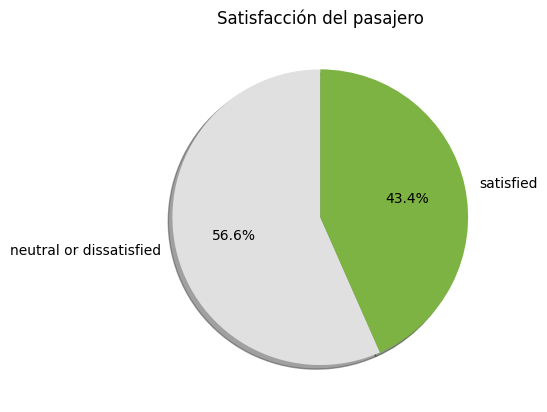

In [16]:
fig, ax = plt.subplots()
ax.pie(df_train.satisfaction.value_counts(), labels=df_train.satisfaction.unique(), shadow=shadow_dict,
       colors=[unsatisfied_color, satisfied_color], autopct='%1.1f%%', startangle=90)
plt.title("Satisfacción del pasajero")
plt.show()

In [17]:
#validamos la proporción de target en test
df_test.satisfaction.value_counts(dropna=False,normalize=True)

,proportion
satisfaction,
neutral or dissatisfied,0.562904
satisfied,0.437096


Como podemos notar, las clases estan relativamente balanceadas, aunque predominan los usuarios insatisfechos o neutrales.

In [18]:
#Codificamos la variable target
df_train['target'] = np.where(df_train['satisfaction']=='satisfied',1,0)
df_test['target'] = np.where(df_test['satisfaction']=='satisfied',1,0)
df_train = df_train.drop(['satisfaction'], axis=1)
df_test = df_test.drop(['satisfaction'], axis=1)

### FEATURES

DISTRIBUCION: Lo primero que queremos observar es como se distribuyen las distintas variables que utilizaremos para la predicción

#### PASAJERO

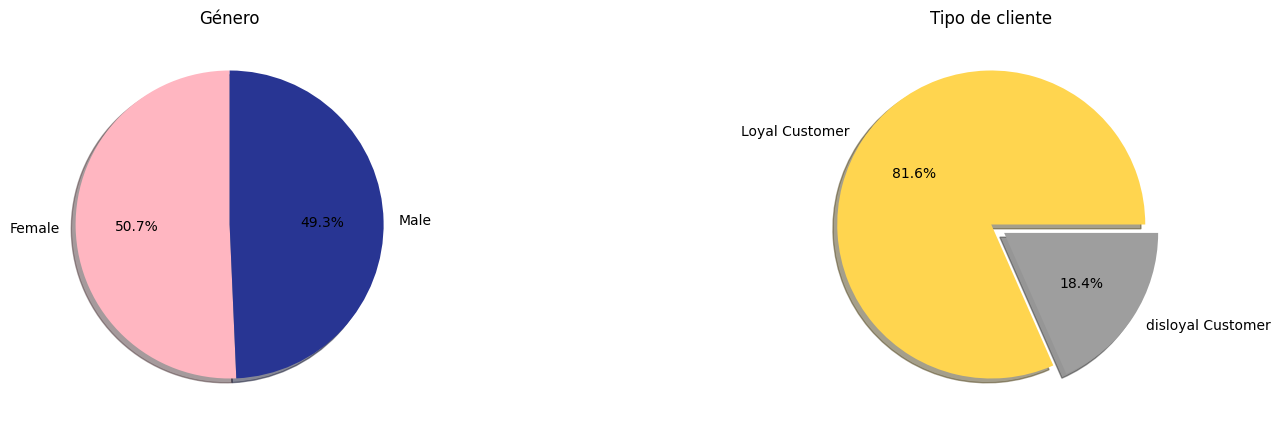

In [19]:
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
gender_series = df_train.Gender.value_counts()
ax1.pie(gender_series, labels=gender_series.index, shadow=shadow_dict, colors=[female_color, male_color],
        autopct='%1.1f%%', startangle=90)
ax1.set_title("Género")


customer_type_series = df_train['Customer Type'].value_counts()
ax2.pie(customer_type_series, labels=customer_type_series.index, colors=[loyal_color, disloyal_color], explode=(0, 0.1),
        shadow=shadow_dict, autopct='%1.1f%%')
ax2.set_title("Tipo de cliente")
plt.subplots_adjust(wspace=0.9)
plt.show()

CONCLUSIONES:
- Como podemos observar la distribución de hombres y mujeres está bien balanceada.
- Respecto al Tipo de Cliente observamos que los que respondieron las encuestas son mayoritariamente "Loyal Customer". Esto se puede explicar debido a que los clientes leales tienden a estar más interesados en proporcionar retroalimentación respecto a la calidad de servicio que reciben y desean verlo mejorar. A su vez, estos pueden estar incentivados por la aerolínea con recompensas de distinto tipo, como millas adicionales.

A los efectos de ilustrar las edades, separamos las mismas en etapas de vida como continuación detallamos:
* Infancia: de 0 a 13 años
* Adolescencia: de 13 a 18 años
* Jóvenes adultos: de 18 a 25 años
* Adultos jóvenes: de 25 a 35 años
* Adultos medios: de 35 a 45 años
* Adultos mayores: de 45 a 55 años
* Prejubilación: 55 a 65 años
* Jubilación y tercera edad: 65 años en adelante

In [20]:
def clasificar_etapa_vida(edad):
    if edad < 13:
        return 'Infancia'
    elif edad < 18:
        return 'Adolescencia'
    elif edad < 25:
        return 'Jóvenes adultos'
    elif edad < 35:
        return 'Adultos jóvenes'
    elif edad < 45:
        return 'Adultos medios'
    elif edad < 55:
        return 'Adultos mayores'
    elif edad < 65:
        return 'Prejubilación'
    else:
        return 'Jubilación y tercera edad'


df_train['Age Stage'] = df_train['Age'].apply(clasificar_etapa_vida)
etapas_orden = ['Infancia', 'Adolescencia', 'Jóvenes adultos', 'Adultos jóvenes',
                'Adultos medios', 'Adultos mayores', 'Prejubilación',
                'Jubilación y tercera edad']
df_train['Age Stage'] = pd.Categorical(df_train['Age Stage'], categories=etapas_orden, ordered=True)

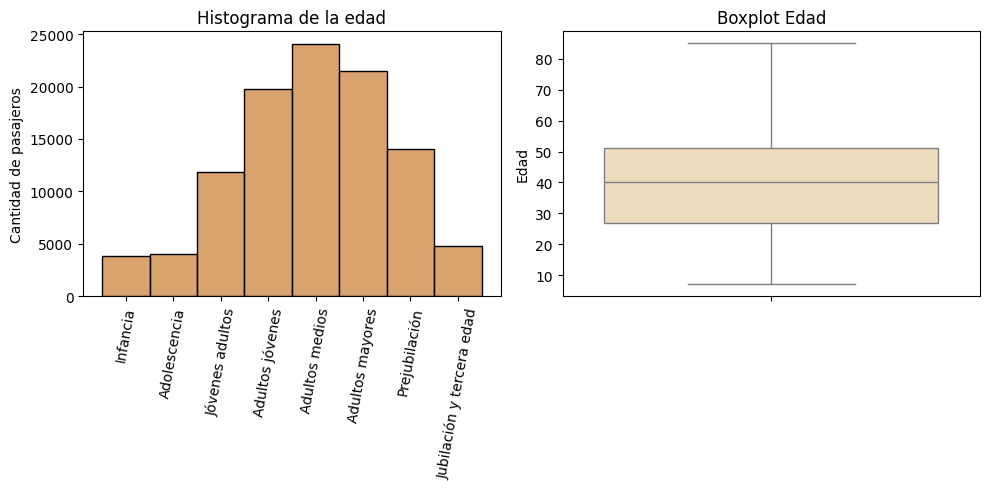

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

sns.histplot(df_train ,x='Age Stage', ax=ax1, color='peru')
ax1.set_title('Histograma de la edad')
ax1.set_ylabel('Cantidad de pasajeros')
ax1.set_xlabel('')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=80)

sns.boxplot(y='Age', data=df_train, ax=ax2, color='wheat')
ax2.set_title('Boxplot Edad')
ax2.set_ylabel('Edad')

plt.tight_layout()

plt.show()


In [22]:
df_train['Age Stage'].value_counts(normalize=True)

,proportion
Age Stage,
Adultos medios,0.231541
Adultos mayores,0.206412
Adultos jóvenes,0.190493
Prejubilación,0.135356
Jóvenes adultos,0.114221
Jubilación y tercera edad,0.045927
Adolescencia,0.038940
Infancia,0.037111


In [23]:
df_train = df_train.drop(['Age Stage'], axis=1)

CONCLUSIONES:
* Observamos que los clientes con edades dentro de Adultos Medios y Adultos Mayores son la proporción mayoritaria que realizó la encuesta. Al rededor del 63 %.
* Notamos que al rededor de 7 % de los encuestados se encuentran dentro de rango de edades Infancia (3.7%) y Adolescencia (3.9%). Creemos que los registros que se encuentran en el rango infancia no serían válidos, por lo que podríamos eliminarlos. No obstante ello, al no poder contar con más información respecto sobre cómo se realizó la encuesta decidimos mantenerlos.

#### VIAJE

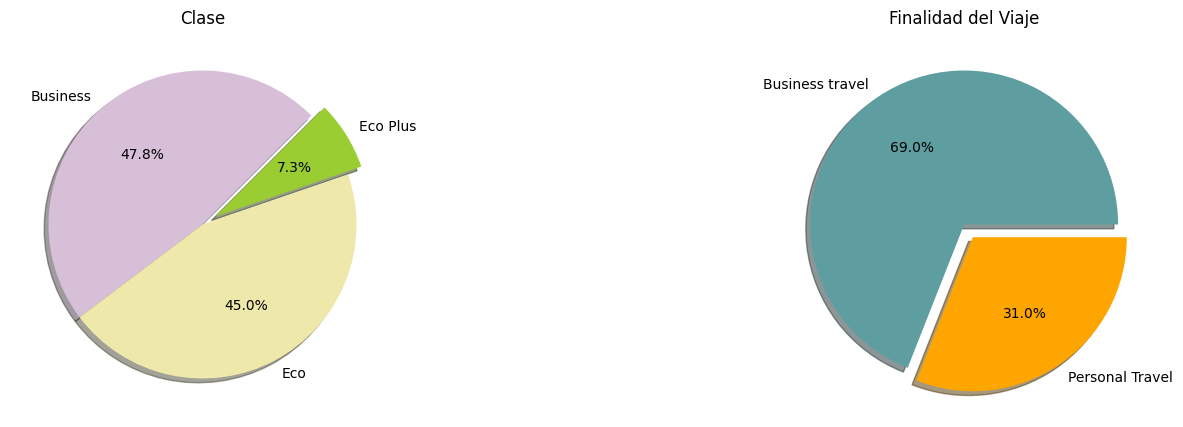

In [24]:
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
class_series = df_train['Class'].value_counts()
ax1.pie(class_series, labels=class_series.index, explode=(0, 0, 0.1), shadow=shadow_dict,
        colors=[business_class_color, eco_class_color, eco_plus_class_color], autopct='%1.1f%%', startangle=45)
ax1.set_title("Clase")


travel_type_series = df_train['Type of Travel'].value_counts()
ax2.pie(travel_type_series, labels=travel_type_series.index, colors=[business_travel_color, personal_travel_color],
        explode=(0, 0.1), shadow=shadow_dict, autopct='%1.1f%%')
ax2.set_title("Finalidad del Viaje")
plt.subplots_adjust(wspace=0.9)
plt.show()

CONCLUSIONES:
* La mayoría de los usuarios viajan por trabajo y no por motivos personales.
* Muy pocos usuarios tienen como clase Eco Plus.

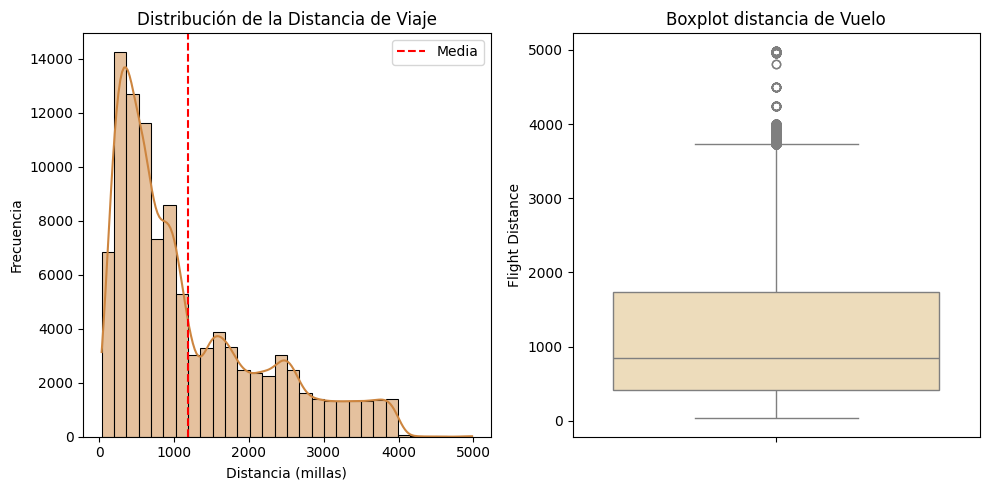

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

sns.histplot(df_train['Flight Distance'], bins=30, kde=True, ax=ax1, color='peru')
# Añadir una línea de media
ax1.axvline(df_train['Flight Distance'].mean(), color='red', linestyle='--', label='Media')
ax1.set_title('Distribución de la Distancia de Viaje')
ax1.set_xlabel('Distancia (millas)')
ax1.set_ylabel('Frecuencia')
ax1.legend()

sns.boxplot(y='Flight Distance', data=df_train, ax=ax2, color='wheat')
ax2.set_title('Boxplot distancia de Vuelo')
ax2.set_ylabel('Flight Distance')

plt.tight_layout()

plt.show()


CONCLUSIONES:
* Respecto de la distancia, segun las observaciones con las que contamos, la aerolinea parece hacer más vuelos cortos que largos.
* Se observan algunos valores atípicos en el boxplot

#### SERVICIOS RELACIONADOS CON LA EXPERIENCIA DE VUELO

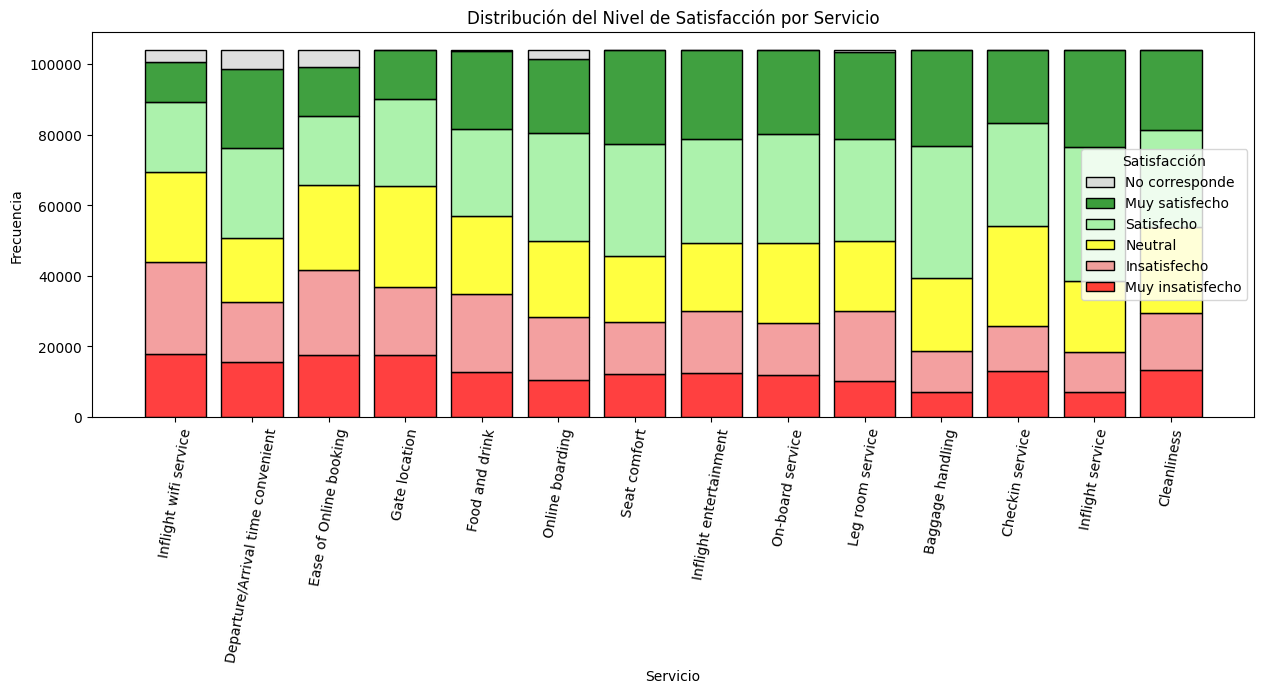

In [26]:
fig, ax = plt.subplots(figsize=(15, 5))

mapeo_satisfaccion = {
    0: "No corresponde",
    1: "Muy insatisfecho",
    2: "Insatisfecho",
    3: "Neutral",
    4: "Satisfecho",
    5: "Muy satisfecho"
}

# Contamos la frecuencia de cada nivel de satisfacción por servicio
df_melted = df_train.melt(value_vars=satisfaction_columns, var_name='Servicio', value_name='Satisfacción')

paleta_colores = sns.color_palette(['lightgrey', 'green', 'lightgreen', 'yellow', 'lightcoral', 'red'])
df_melted['Satisfacción'] = df_melted['Satisfacción'].map(mapeo_satisfaccion)
df_melted['Satisfacción'] = pd.Categorical(df_melted['Satisfacción'], categories=['No corresponde', 'Muy satisfecho', 'Satisfecho', 'Neutral', 'Insatisfecho', 'Muy insatisfecho' ])  # Convertir a string para usar hue

# Gráfico de barras apiladas
sns.histplot(df_melted, x='Servicio', hue='Satisfacción', multiple='stack', palette=paleta_colores, shrink=0.8, ax=ax)
plt.xticks(rotation=80)
ax.set_title('Distribución del Nivel de Satisfacción por Servicio')
plt.xlabel('Servicio')

plt.ylabel('Frecuencia')

plt.show()


CONCLUSIONES:
* Son pocos los pasajeros que no votan sobre la experiencia de un servicio/no les corresponde responder.
* En general, la opción más votada es la 4.

#### RENDIMIENTO DE VUELO

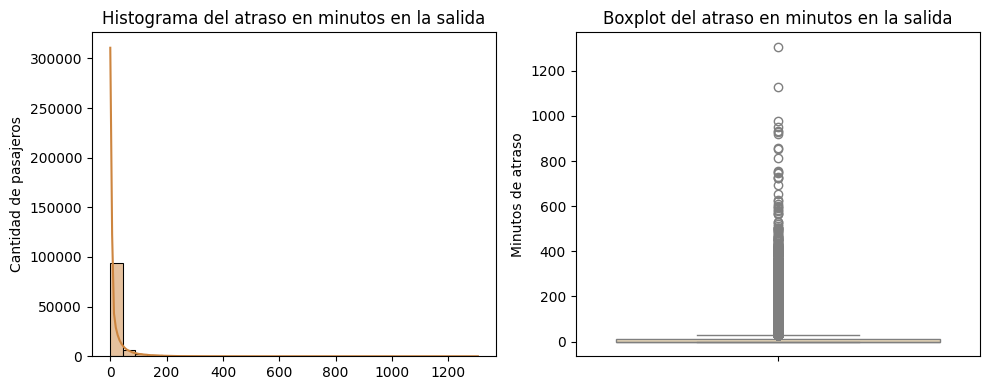

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df_train ,x='Departure Delay in Minutes', kde=True, bins=30, ax=ax1, color='peru')
ax1.set_title('Histograma del atraso en minutos en la salida')
ax1.set_ylabel('Cantidad de pasajeros')
ax1.set_xlabel('')

sns.boxplot(y='Departure Delay in Minutes', data=df_train, ax=ax2, color='wheat')
ax2.set_title('Boxplot del atraso en minutos en la salida')
ax2.set_ylabel('Minutos de atraso')

plt.tight_layout()

plt.show()

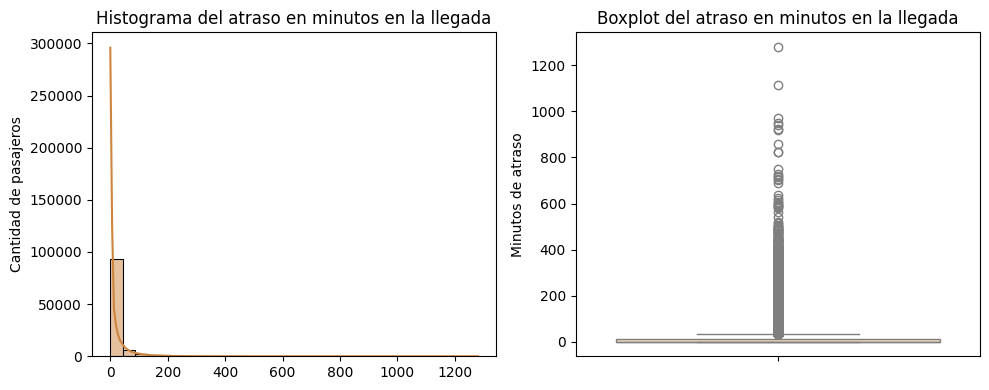

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

sns.histplot(df_train ,x='Arrival Delay in Minutes', kde=True, bins=30, ax=ax1, color='peru')
ax1.set_title('Histograma del atraso en minutos en la llegada')
ax1.set_ylabel('Cantidad de pasajeros')
ax1.set_xlabel('')

sns.boxplot(y='Arrival Delay in Minutes', data=df_train, ax=ax2, color='wheat')
ax2.set_title('Boxplot del atraso en minutos en la llegada')
ax2.set_ylabel('Minutos de atraso')

plt.tight_layout()

plt.show()

CONCLUSIONES:
* Las variables de demora en la salida y demora en la llegada, presentan en su distribución una cola pesada hacia la derecha, por lo tanto tambien se ven outliers.


CORRELACION ENTRE LAS FEATURES

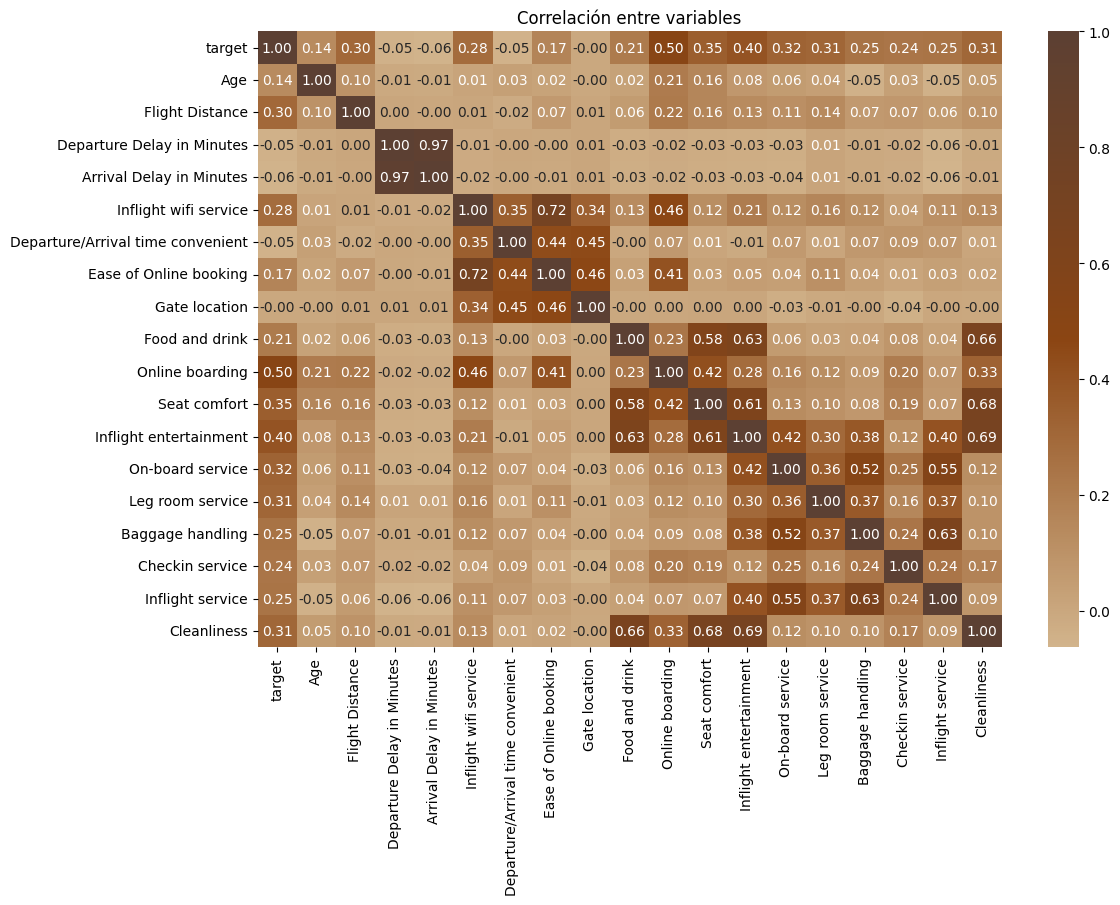

In [29]:
# correlación entre variables
import matplotlib.colors as mcolors
brown_palette = mcolors.LinearSegmentedColormap.from_list("brown_degrade", ["#D2B48C", "#8B4513", "#5C4033"])

correlation_matrix=df_train[target + num_dis+ [i for i in cualitativas_ord if i not in ['Class']]].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True , fmt=".2f", cmap=brown_palette)
plt.title('Correlación entre variables')
plt.show()

In [30]:
high_correlation = correlation_matrix[(correlation_matrix != 1)]

result = high_correlation.stack().reset_index()
result.columns = ['Feature_1', 'Feature_2', 'Correlacion']
result = result[result['Feature_1'] < result['Feature_2']]

positive_correlations = result[result['Correlacion'] > 0]
negative_correlations = result[result['Correlacion'] < 0]

print("Top 10 correlaciones positivas:")
display(positive_correlations.sort_values(by='Correlacion',ascending=False).head(10))

print("\nTop 10 correlaciones negativas:")
display(negative_correlations.sort_values(by='Correlacion',ascending=True).head(10))

Top 10 correlaciones positivas:


,Feature_1,Feature_2,Correlacion
75,Arrival Delay in Minutes,Departure Delay in Minutes,0.965626
131,Ease of Online booking,Inflight wifi service,0.716285
336,Cleanliness,Inflight entertainment,0.693987
335,Cleanliness,Seat comfort,0.679908
333,Cleanliness,Food and drink,0.659649
286,Baggage handling,Inflight service,0.631047
173,Food and drink,Inflight entertainment,0.626097
227,Inflight entertainment,Seat comfort,0.612238
172,Food and drink,Seat comfort,0.576945
319,Inflight service,On-board service,0.553085



Top 10 correlaciones negativas:


,Feature_1,Feature_2,Correlacion
88,Arrival Delay in Minutes,Inflight service,-0.063509
70,Departure Delay in Minutes,Inflight service,-0.058191
72,Arrival Delay in Minutes,target,-0.056952
108,Departure/Arrival time convenient,target,-0.054815
34,Age,Inflight service,-0.050944
54,Departure Delay in Minutes,target,-0.049494
32,Age,Baggage handling,-0.047178
296,Checkin service,Gate location,-0.040966
84,Arrival Delay in Minutes,On-board service,-0.036842
66,Departure Delay in Minutes,On-board service,-0.033189


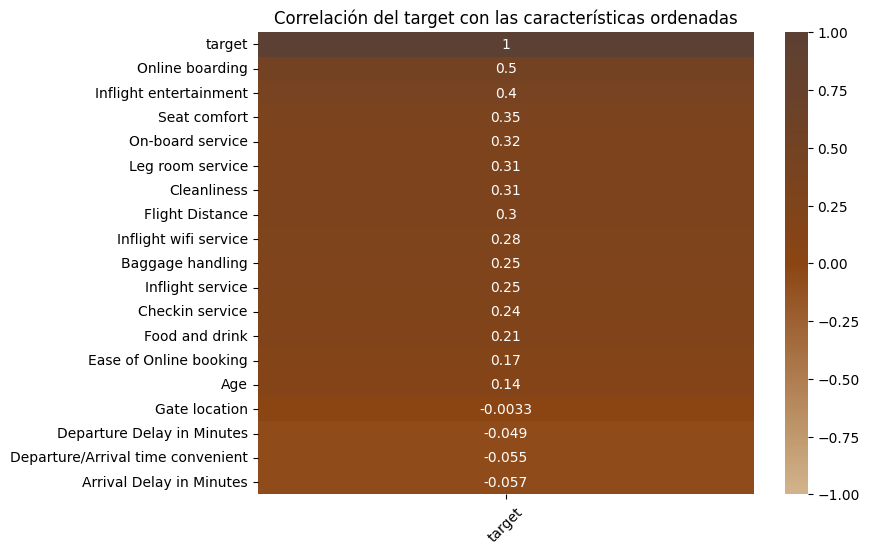

In [31]:
correlation_target = correlation_matrix[['target']]  .sort_values(by='target', ascending=False)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_target, annot=True, vmin=-1, vmax=1, cmap=brown_palette)
plt.title('Correlación del target con las características ordenadas')
plt.xticks(rotation=45)
plt.show()

CONCLUSIONES:

Como era de esperar, vemos una correlación muy alta (0.97) entre la demora en salir y la demora en llegar en el avión.

Además vemos otras relaciones menos intuitivas:
* alta correlación (0.72) entre facilidad para la compra online y el servicio de wifi en el avión.
* alta correlación (0.69) entre la limpieza y el entretenimiento a bordo.
* alta correlación (0.68) entre la limpieza y la comodidad del asiento
* alta correlación (0.66) entre la limpieza y la conformidad en los alimentos


Algo importante a destacar, es que no se observa correlación negativa alta entre ninguna feature (max: -0.06)

Respecto a la correlación de las features con el target, vemos que Online Boarding es la que presenta mayor correlación, seguida por el entretenimiento a bordo.

ANALISIS BIVARIADO

Este análisis nos permitiría descartar features que veamos que no discriminen el target

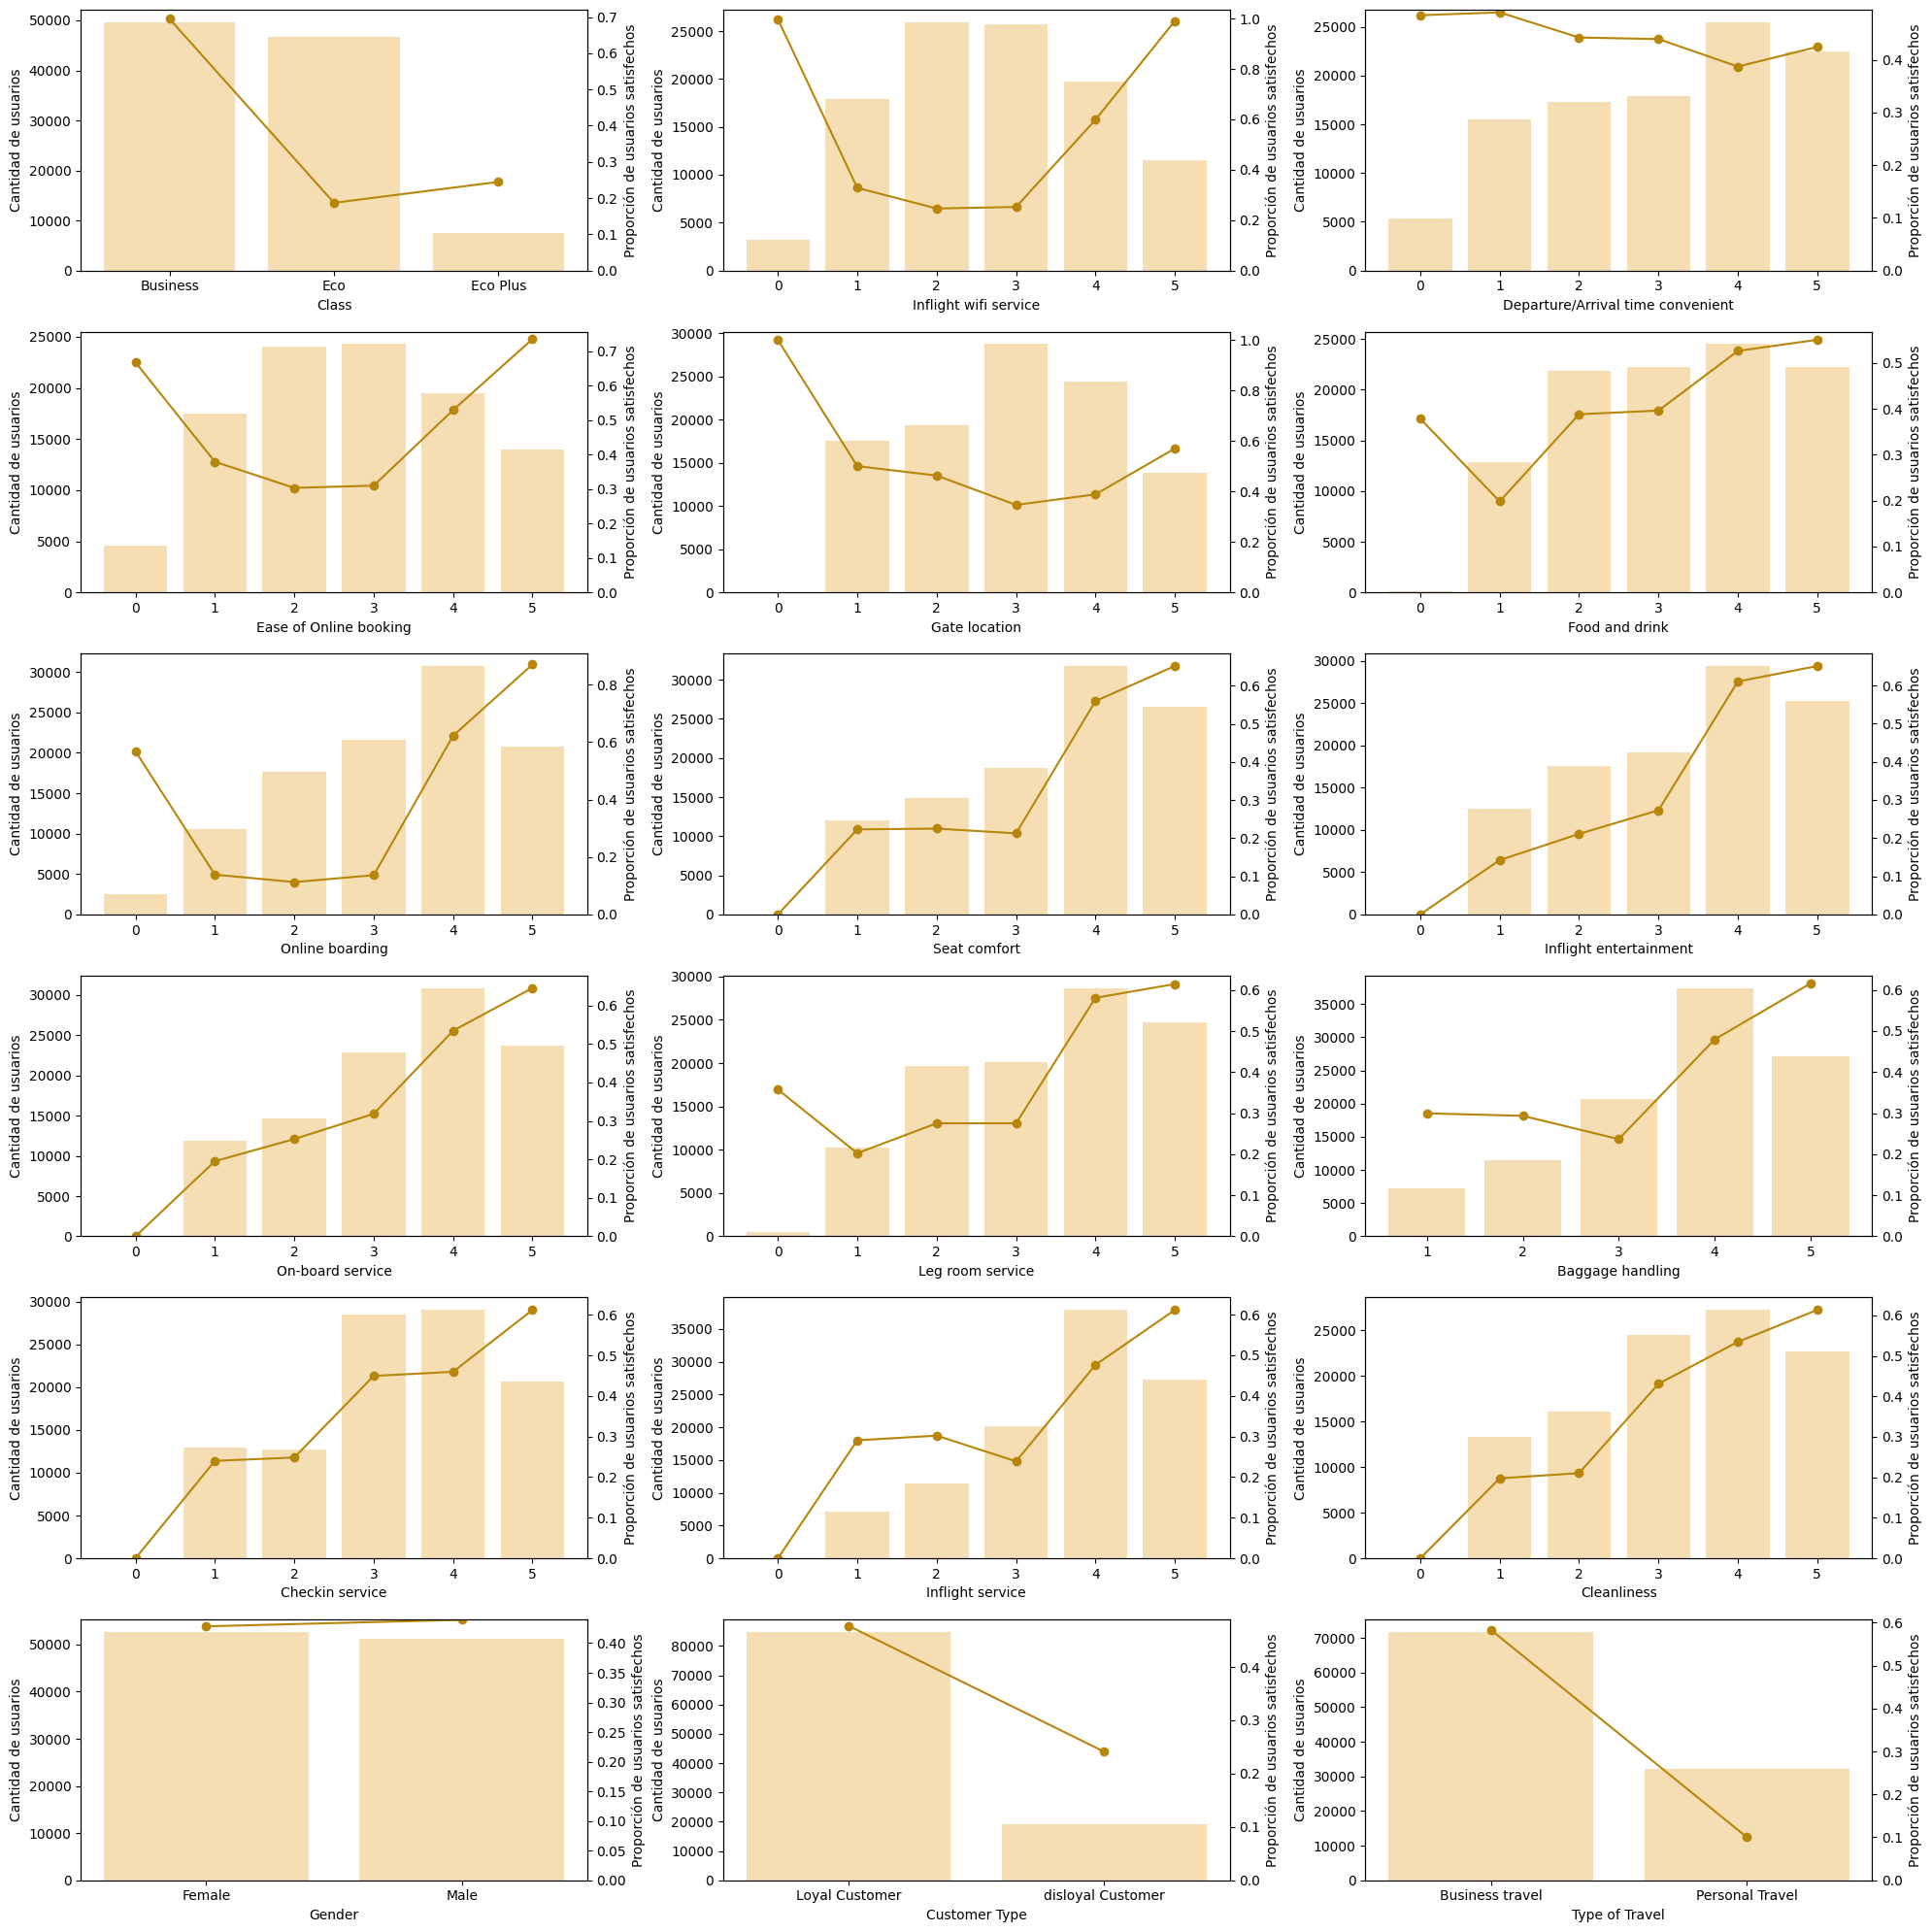

In [32]:
cols = cualitativas_ord + cualitativas_nom
ncols = 3
nrows = (len(cols) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 20))

for i, col in enumerate(cols):
    row = i // ncols
    col_idx = i % ncols

    ax1 = axes[row, col_idx]
    a = pd.DataFrame(df_train.groupby(col).agg({'target': ['count', 'sum']})).reset_index()
    a.columns = [col, 'q', 'target']
    a['prop_target'] = a['target'] / a['q']

    ax1.bar(a[col], a['q'], color='wheat')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Cantidad de usuarios')

    ax2 = ax1.twinx()
    ax2.plot(a[col], a['prop_target'], color='darkgoldenrod', marker='o')
    ax2.set_ylabel('Proporción de usuarios satisfechos')
    ax2.set_ylim(bottom=0)

    ax1.tick_params(axis='y')
    ax2.tick_params(axis='y')


for j in range(len(cols), nrows * ncols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

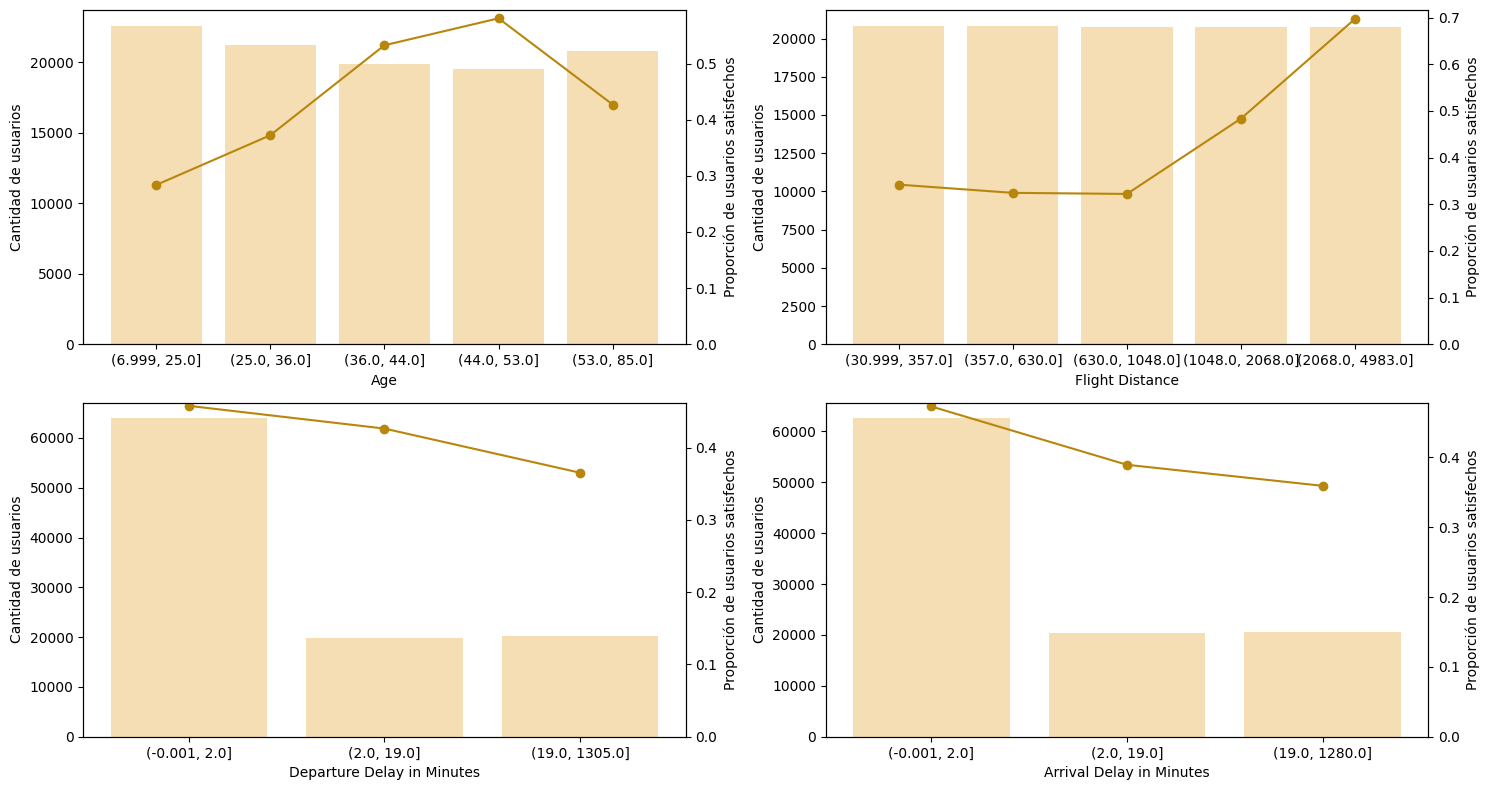

In [33]:
ncols = 2  # Número de columnas en la cuadrícula de subgráficas
nrows = (len(num_dis) + ncols - 1) // ncols  # Calcular el número de filas necesarias

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))  # Ajustar tamaño de la figura

for i, col in enumerate(num_dis):
    row = i // ncols
    col_idx = i % ncols

    ax1 = axes[row, col_idx]
    b = df_train.copy()
    b['bins'] = pd.qcut(df_train[col], q=5, duplicates='drop')
    a = pd.DataFrame(b.groupby('bins').agg({'target': ['count', 'sum']})).reset_index()
    a.columns = [col, 'q', 'target']
    a['prop_target'] = a['target'] / a['q']
    a_sorted = a.sort_values(by=col)

    ax1.bar(a_sorted[col].astype(str), a_sorted['q'], color='wheat')
    ax1.set_xlabel(col)
    ax1.set_ylabel('Cantidad de usuarios')
    ax1.tick_params(axis='y')

    ax2 = ax1.twinx()
    ax2.plot(a_sorted[col].astype(str), a_sorted['prop_target'], color='darkgoldenrod', marker='o')
    ax2.set_ylabel('Proporción de usuarios satisfechos')
    ax2.tick_params(axis='y')
    ax2.set_ylim(bottom=0)

# Eliminar subgráficas vacías si hay más subgráficas que variables
for j in range(len(num_dis), nrows * ncols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

CONCLUSIONES:
- La variable de género no distingue la satisfacción de los pasajeros.
- La variable de clase distingue muy bien la tasa de satisfacción: los usuarios de económica suelen estar mas insatisfechos que aquellos que viajan en primera.
- Muchas variables presentan un ordenamiento monotónico creciente con la tasa de satisfacción (a más alto el voto, más proporción de pasajeros satisfechos): comida y bebida, espacio para las piernas, servicio a bordo, servicio de check in, limpieza, entre otras.
- Aquellos que viajan por trabajo, tambien se encuentran más conformes con la aerolinea.
- Los clientes frecuentres (loyal) suelen estar más contentos con el servicio brindado que aquellos que no lo son.
- Tanto la demora en el arribo como en la llegada, presentan una relación inversa con el target: a más demora, más insatisfechos estan. Sin embargo, no se ve una diferencia tan significativa en el target.
- A mayor distancia de viaje, los usuarios presentan mayor conformidad. Esto puede deberse a que se ponen a disposición mejores aviones para viajes más largos.
- Respecto de la edad, el rango etario con mayores tasas de conformidad son los adultos entre 44 y 53 años.

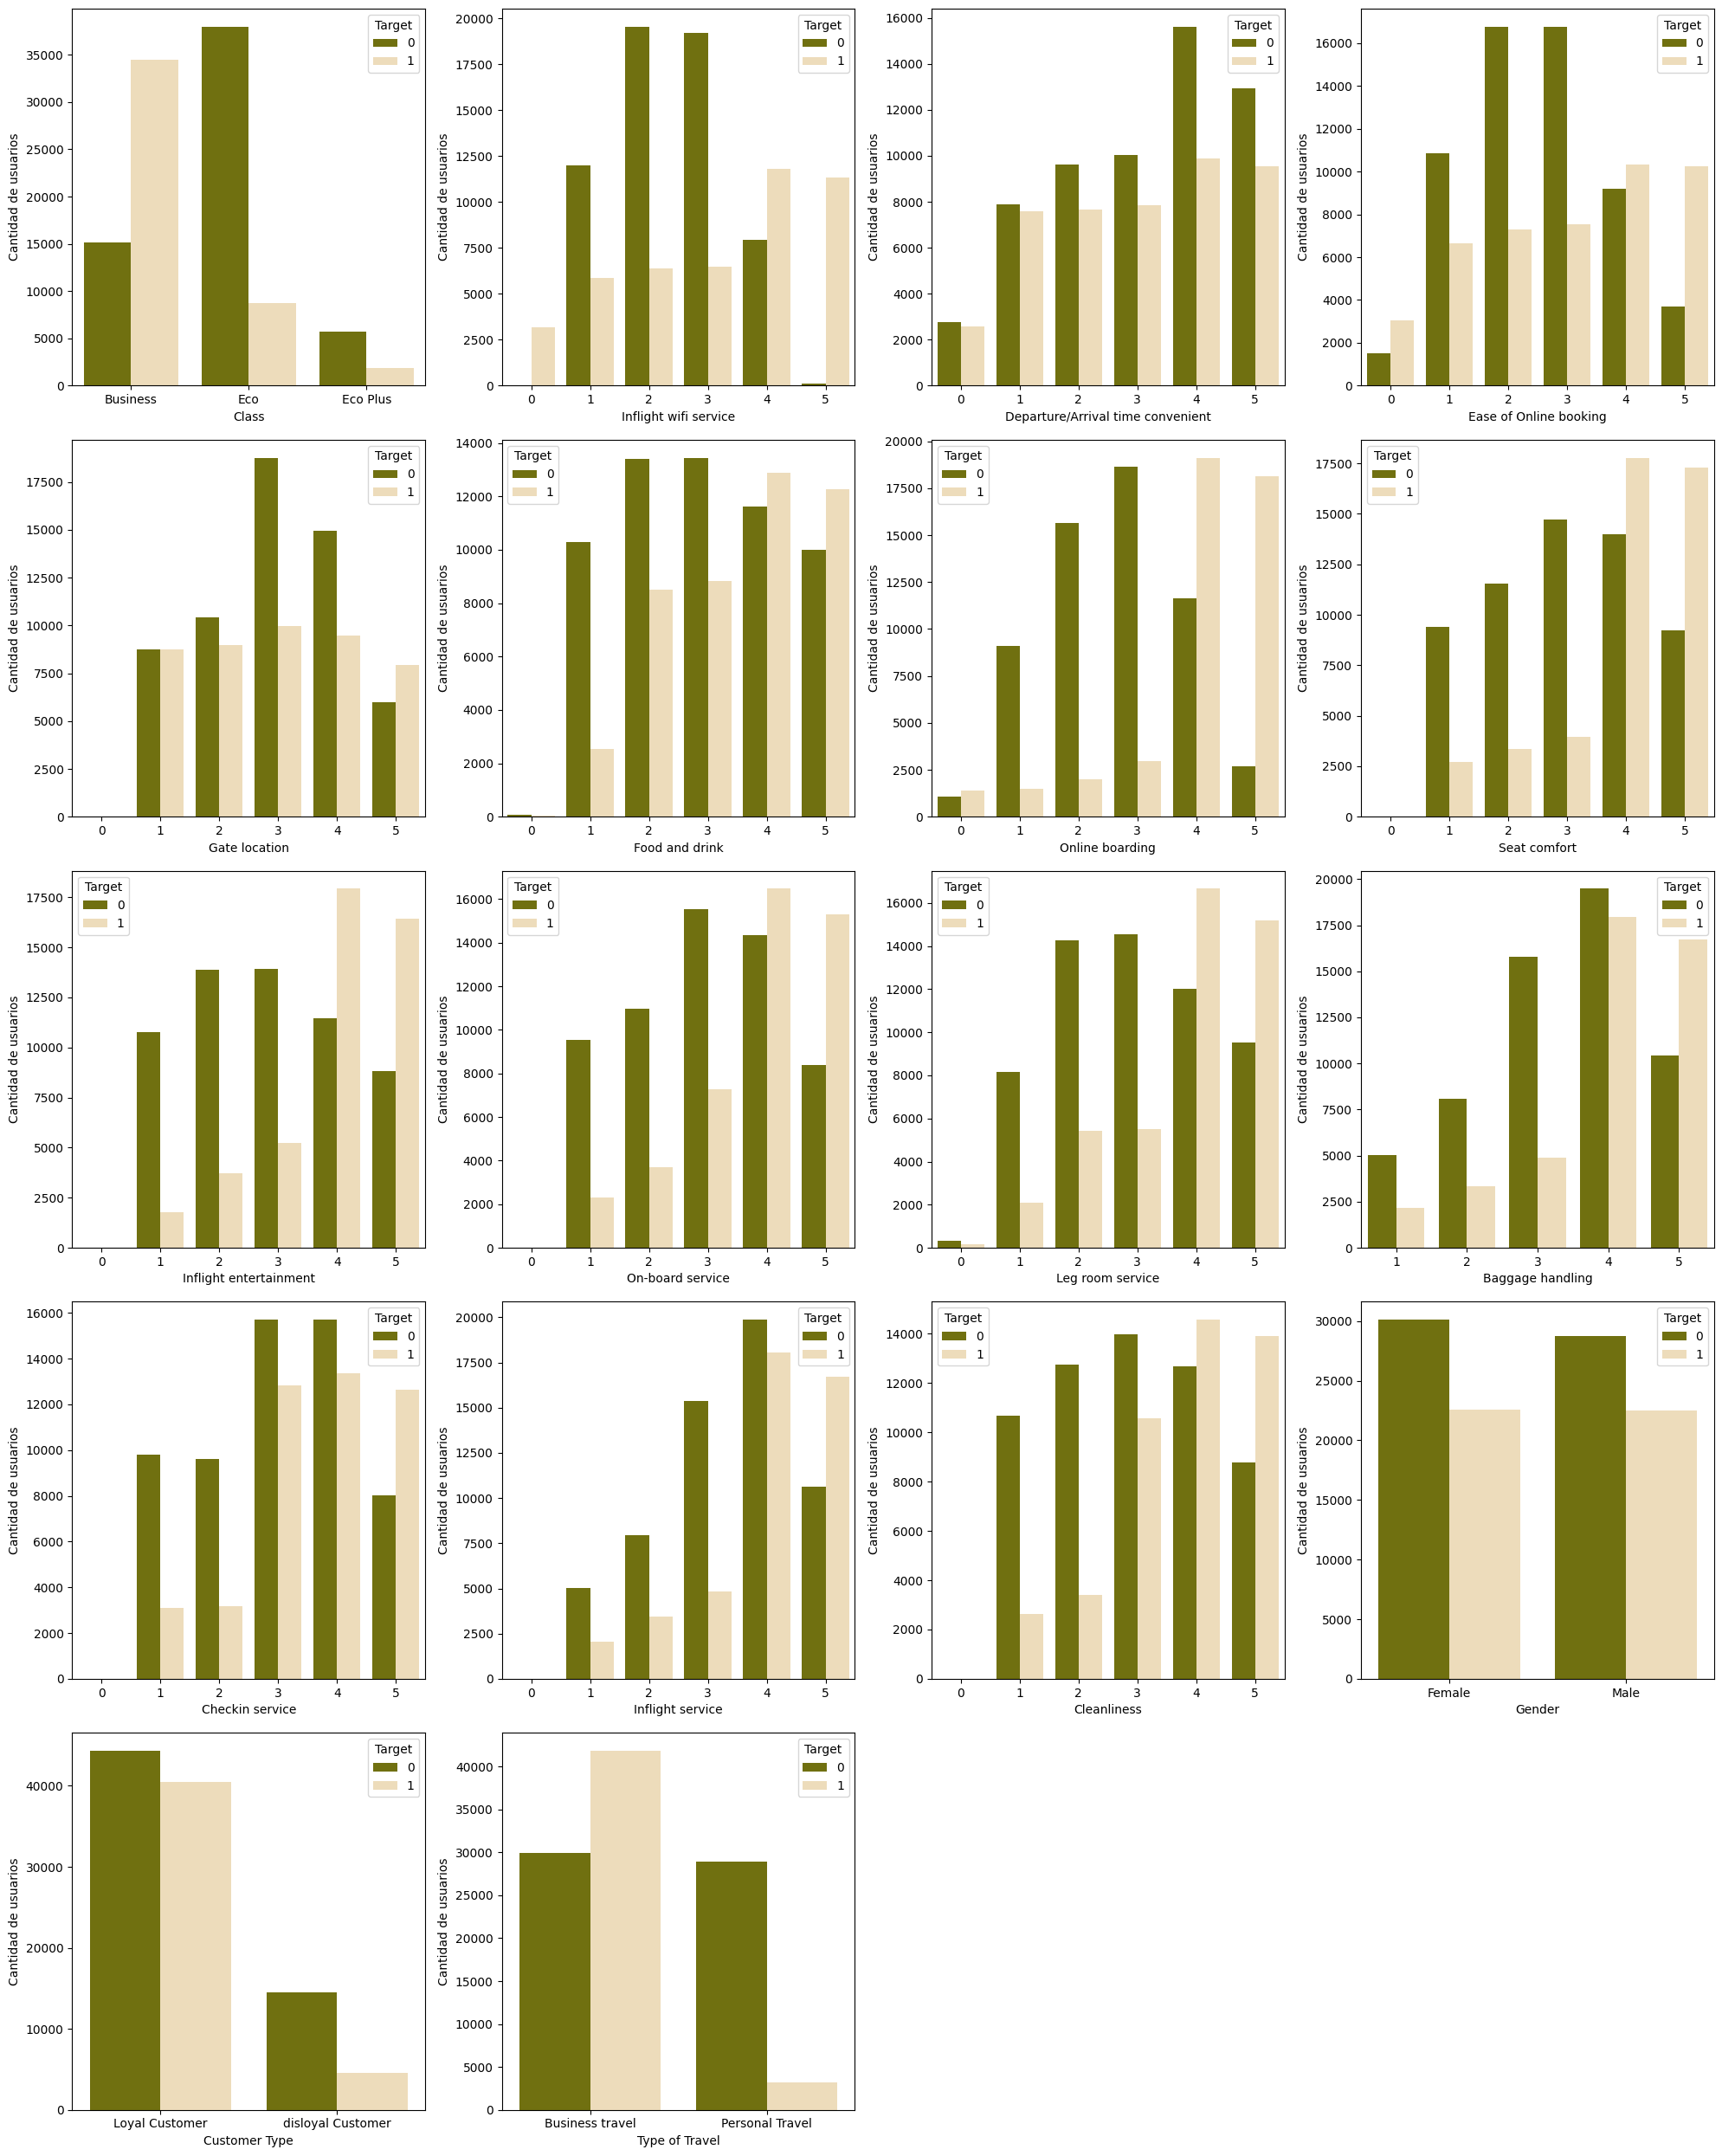

In [34]:
#Otra opción de visualización de las variables cualitativas y la proporción de target
cols = cualitativas_ord + cualitativas_nom
ncols = 4
nrows = (len(cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows), squeeze=False)

for i, col in enumerate(cols):
    row = i // ncols
    col_idx = i % ncols

    ax1 = axes[row, col_idx]
    a = pd.DataFrame(df_train.groupby([col, 'target']).size()).reset_index()
    a.columns = [col, 'target', 'q']

    sns.barplot(data=a, x=col, y='q', hue='target', palette=['olive', 'wheat'], ax=ax1)
    ax1.set_xlabel(col)
    ax1.set_ylabel('Cantidad de usuarios')
    ax1.tick_params(axis='y')


    ax1.legend(title='Target')

# Eliminar subgráficas vacías si hay más subgráficas que variables
for j in range(len(cols), nrows * ncols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

### INGENIERIA DE FEATURES

CODIFICACION DE VARIABLES CATEGORICAS

In [35]:
#La variable de Class tiene un ordenamiento implícito (Business es mejor que Eco Plus y Eco Plus es mejor que Eco), con lo cual vamos a usar un encodeo ordinal
ordered_categories = ['Eco', 'Eco Plus', 'Business']
encoder_ord = OrdinalEncoder(categories=[ordered_categories])

# Ajustamos y transformamos los datos
df_train['Class'] = encoder_ord.fit_transform(df_train[['Class']])
df_test['Class'] = encoder_ord.transform(df_test[['Class']])

In [36]:
#Para las variables cualitativas nominales, decidimos convertirlas en dummies, eliminando la categoría que resulta redundante.
df_train = pd.get_dummies(df_train, columns=cualitativas_nom, drop_first=True)
bool_columns = [col for col in df_train.columns if df_train[col].dtype == 'bool']
df_train[bool_columns] = df_train[bool_columns].astype(int)

df_test = pd.get_dummies(df_test, columns=cualitativas_nom, drop_first=True)
bool_columns = [col for col in df_test.columns if df_test[col].dtype == 'bool']
df_test[bool_columns] = df_test[bool_columns].astype(int)

print(f'Shape df_train: {df_train.shape}')
display(df_train.head(3))

print(f'Shape df_test: {df_test.shape}')
display(df_test.head(3))

Shape df_train: (103904, 23)


,Age,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,target,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel
0,64,2.0,965,3,5,3,3,5,5,5,1,1,3,1,5,1,5,11,4.0,0,0,0,1
1,26,2.0,592,2,1,1,2,3,1,3,3,5,4,5,4,4,3,112,125.0,0,1,1,0
2,8,0.0,993,3,4,3,1,4,3,4,4,4,5,5,4,4,4,0,0.0,0,0,0,1


Shape df_test: (25976, 23)


,Age,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,target,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel
0,66,0.0,1678,3,2,3,2,4,3,4,4,4,3,2,3,2,4,0,0.0,0,1,0,1
1,38,2.0,954,2,2,2,2,2,3,1,4,4,4,4,2,4,4,3,0.0,1,0,0,0
2,38,0.0,189,2,1,1,1,2,2,2,2,1,2,4,1,4,2,0,0.0,0,0,0,0


DATOS FALTANTES

In [37]:
#Observamos cuantas features tenemos con missings
missings = pd.DataFrame(df_train.isnull().sum()).reset_index()
missings.columns = ['Variable', 'Cantidad Missings']
missings['Proporcion Missings'] = missings['Cantidad Missings']/df_train.shape[0]
missings

,Variable,Cantidad Missings,Proporcion Missings
0,Age,0,0.000000
1,Class,0,0.000000
2,Flight Distance,0,0.000000
3,Inflight wifi service,0,0.000000
4,Departure/Arrival time convenient,0,0.000000
5,Ease of Online booking,0,0.000000
6,Gate location,0,0.000000
7,Food and drink,0,0.000000
8,Online boarding,0,0.000000
9,Seat comfort,0,0.000000


Como podemos observar, la única feature que tiene missings es Arrival Delay in Minutes.
Para imputar los missings, proponemos las siguientes opciones:
- Imputar por la media de la variable.
- Imputar el atraso en la salida al atraso en la llegada, ya que uno esperaría que si el avion se atrasa en la salida tambien se atrase en la llegada (lo cual ya se verificó cuando revisamos la correlacion entre ambas variables).
- Hacer un modelo para imputar el atraso en la llegada.

In [38]:
imp_missings = df_train.copy()

#Imputar por la media
imp_missings['Arrival_imp1'] = imp_missings['Arrival Delay in Minutes'].fillna(imp_missings['Arrival Delay in Minutes'].mean())

#Imputar por la demora en la salida
imp_missings['Arrival_imp2'] = np.where(imp_missings['Arrival Delay in Minutes'].isnull(), imp_missings['Departure Delay in Minutes'], imp_missings['Arrival Delay in Minutes'])

#Imputar con KNN
scaler = StandardScaler() #Escalamos el dataset
scaled_features = scaler.fit_transform(imp_missings[[i for i in imp_missings.columns if i not in ['Arrival_imp1', 'Arrival_imp2', 'target']]])
knn_imputer = KNNImputer(n_neighbors=5)
imputed_knn = knn_imputer.fit_transform(scaled_features)
aux= pd.DataFrame(columns = [i for i in imp_missings.columns if i not in ['Arrival_imp1', 'Arrival_imp2', 'target']], data = scaler.inverse_transform(imputed_knn))
aux['Arrival_imp3'] = aux['Arrival Delay in Minutes'].astype('float')
aux['Arrival_imp3'] = np.round(aux['Arrival_imp3'])
aux=aux[['Arrival_imp3']]
imp_missings = imp_missings.join(aux)

imp_missings['Arrival_imp1']= imp_missings['Arrival_imp1'].astype('int')
imp_missings['Arrival_imp2']= imp_missings['Arrival_imp2'].astype('int')
imp_missings['Arrival_imp3']= imp_missings['Arrival_imp3'].astype('int')

imp_missings.head()

,Age,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,target,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Arrival_imp1,Arrival_imp2,Arrival_imp3
0,64,2.0,965,3,5,3,3,5,5,5,1,1,3,1,5,1,5,11,4.0,0,0,0,1,4,4,4
1,26,2.0,592,2,1,1,2,3,1,3,3,5,4,5,4,4,3,112,125.0,0,1,1,0,125,125,125
2,8,0.0,993,3,4,3,1,4,3,4,4,4,5,5,4,4,4,0,0.0,0,0,0,1,0,0,0
3,41,2.0,2223,4,4,4,4,1,2,4,5,5,5,5,5,5,1,9,4.0,1,1,0,0,4,4,4
4,19,0.0,1235,4,4,4,4,3,4,3,3,1,2,4,1,4,3,0,0.0,0,0,1,0,0,0,0


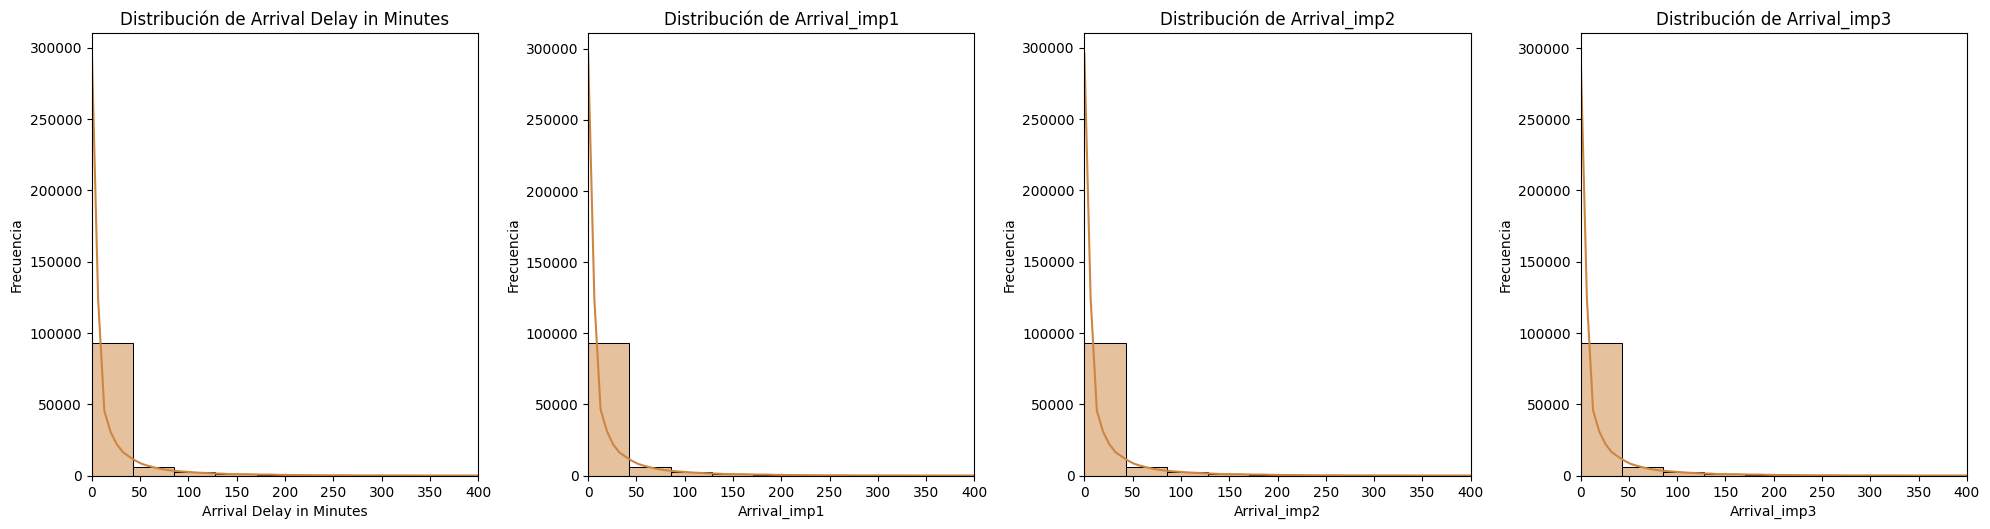

In [39]:
# Distribución variables numéricas discretas
nrows, ncols = 4, 4
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 20))

for i, col in enumerate(['Arrival Delay in Minutes', 'Arrival_imp1', 'Arrival_imp2', 'Arrival_imp3']):
    row = i // ncols
    col_idx = i % ncols
    sns.histplot(imp_missings[col], kde=True, bins=30, ax=axes[row, col_idx], color='peru')
    axes[row, col_idx].set_title(f'Distribución de {col}')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Frecuencia')
    axes[row, col_idx].set_xlim((0,400))

for j in range(i + 1, nrows * ncols):
    fig.delaxes(axes.flatten()[j])
plt.tight_layout()
plt.show()

Las distribuciones se ven muy parecidas porque son muy pocos casos los que tienen missings. Vemos a detalle qué imputacion se hizo para tomar una decision:

In [40]:
imp_missings[imp_missings['Arrival Delay in Minutes'].isnull()].head(30)

,Age,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,target,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Arrival_imp1,Arrival_imp2,Arrival_imp3
20,64,0.0,1814,2,4,3,3,3,4,4,2,2,3,2,5,2,4,10,NaN,0,0,0,1,15,10,17
318,20,2.0,2370,2,2,2,2,3,3,3,3,5,4,5,3,5,3,60,NaN,1,0,0,0,15,60,32
766,34,0.0,213,2,4,2,4,3,2,3,3,5,4,5,4,5,3,0,NaN,0,1,0,1,15,0,4
1494,24,2.0,1310,5,4,5,4,4,5,4,4,4,3,5,5,4,4,125,NaN,1,0,1,0,15,125,90
2089,60,2.0,1197,1,1,1,1,2,4,5,4,4,5,4,4,4,3,24,NaN,1,0,0,0,15,24,4
2090,41,2.0,618,5,5,5,5,4,4,4,3,3,3,3,5,3,5,0,NaN,1,1,0,0,15,0,4
2353,36,0.0,503,2,5,4,4,5,4,5,5,4,3,4,3,5,5,0,NaN,0,1,0,1,15,0,0
4079,49,0.0,491,5,4,5,2,3,5,3,3,1,4,3,3,4,3,0,NaN,1,1,1,1,15,0,0
4304,40,2.0,2075,5,5,5,5,5,5,5,2,2,2,2,4,2,4,0,NaN,1,0,0,0,15,0,0
5262,14,2.0,2515,5,5,5,5,4,4,4,4,4,2,4,5,4,4,8,NaN,1,0,0,0,15,8,0


Decidimos en el caso de esta variable, imputarla por la demora en la salida.

In [41]:
df_train['Arrival Delay in Minutes'] = np.where(df_train['Arrival Delay in Minutes'].isnull(), df_train['Departure Delay in Minutes'], df_train['Arrival Delay in Minutes'])
df_test['Arrival Delay in Minutes'] = np.where(df_test['Arrival Delay in Minutes'].isnull(), df_test['Departure Delay in Minutes'], df_test['Arrival Delay in Minutes'])

Observamos que algunas variables respecto a la satisfaccion del cliente en los distintos servicios, toman valor 0. Esto podria considerarse como que el servicio no aplicó o que el usuario decidió no contestar estas preguntas.
Para evaluar esto, realizamos el siguiente análisis:

<Axes: >

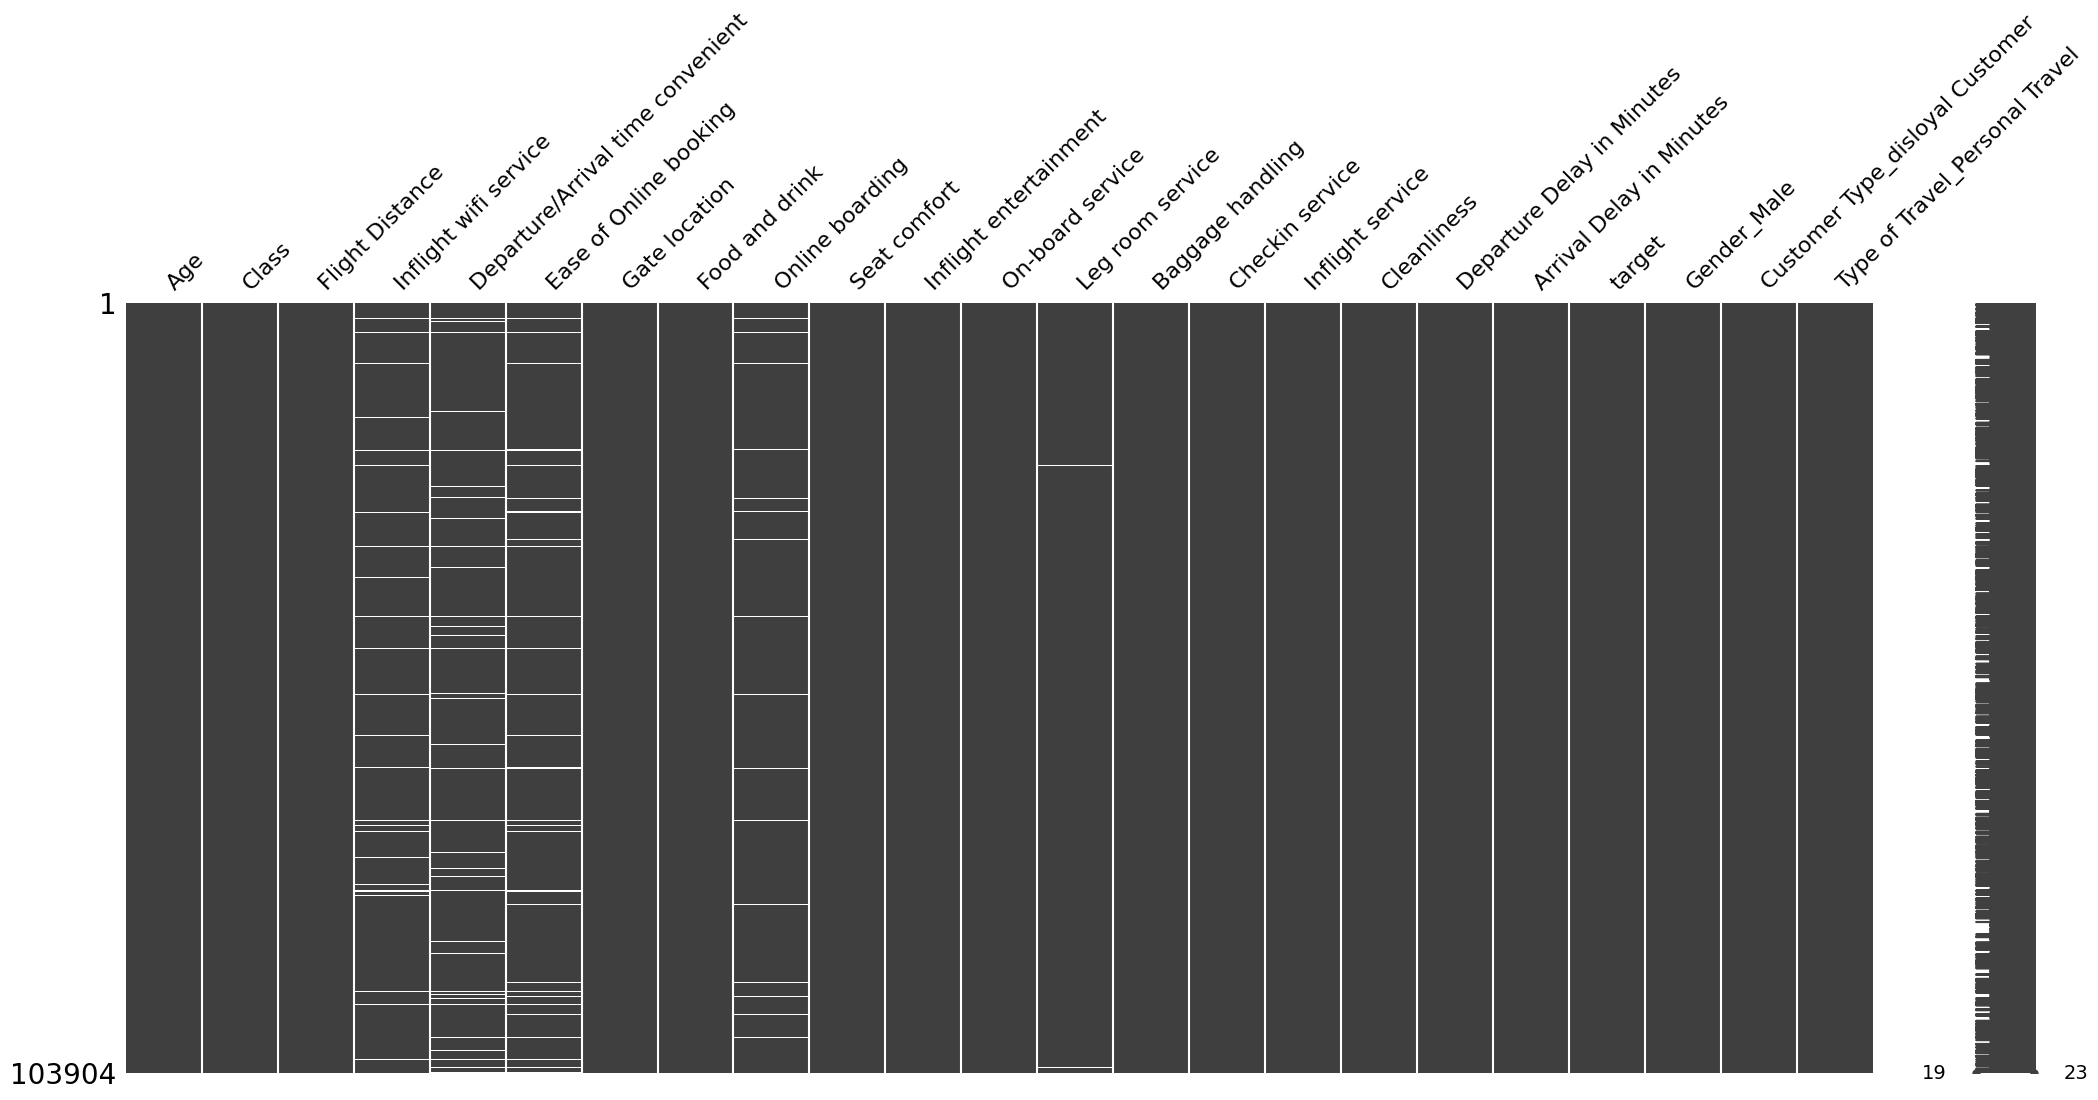

In [42]:
df_train_0 = df_train.copy()

#Cambiamos el valor 0 por missing y vemos si estos missing tienen relacion entre si
for i in [j for j in cualitativas_ord if j not in ['Class']]:
  df_train_0[i] = np.where(df_train_0[i] ==0 , np.nan,df_train_0[i] )

msno.matrix(df_train_0)

No se observa necesariamente una relación entre los missings. Por ende, vamos a revisar cuántos usuarios tenemos que no contestaron más de una feature a la vez.

In [43]:
features_valoraciones = ['Inflight wifi service','Departure/Arrival time convenient', 'Ease of Online booking',
                    'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort','Inflight entertainment',
                    'On-board service', 'Leg room service','Baggage handling', 'Checkin service', 'Inflight service','Cleanliness']
for feat in features_valoraciones:
    df_train_0[feat+'_flag']= np.where(df_train_0[feat].isna(),1,0)

df_train_0['flag_0'] = df_train_0['Inflight wifi service_flag'] +  df_train_0['Departure/Arrival time convenient_flag'] + df_train_0['Ease of Online booking_flag'] + df_train_0['Gate location_flag'] + df_train_0['Food and drink_flag']+ df_train_0['Online boarding_flag'] + df_train_0['Seat comfort_flag'] + df_train_0['Inflight entertainment_flag'] + df_train_0['On-board service_flag'] + df_train_0['Leg room service_flag'] + df_train_0['Baggage handling_flag'] + df_train_0['Checkin service_flag'] + df_train_0['Inflight service_flag'] +  df_train_0['Cleanliness_flag']
aux= pd.DataFrame(df_train_0.groupby(['flag_0', 'target']).size()).reset_index()
aux

,flag_0,target,0
0,0,0,54901
1,0,1,40707
2,1,0,2383
3,1,1,1245
4,2,0,1249
5,2,1,755
6,3,0,289
7,3,1,1771
8,4,0,8
9,4,1,596


Decidimos dejar la categoría de no aplica/no contesta como un 0 (que sería similar a aplicarle un -999) y crear flags que indiquen que el pasajero no respondió o no le aplicó la pregunta.

In [44]:
for i in [j for j in cualitativas_ord if j not in ['Class']]:
	df_train[f'{i}_rta0'] = np.where(df_train[i]==0,1,0)

for i in [j for j in cualitativas_ord if j not in ['Class']]:
	df_test[f'{i}_rta0'] = np.where(df_test[i]==0,1,0)

In [45]:
for i in (feature + '_rta0' for feature in [j for j in cualitativas_ord if j not in ['Class']]):
	display(df_train[i].value_counts(normalize=True))

,proportion
Inflight wifi service_rta0,
0,0.969433
1,0.030567


,proportion
Departure/Arrival time convenient_rta0,
0,0.948645
1,0.051355


,proportion
Ease of Online booking_rta0,
0,0.955728
1,0.044272


,proportion
Gate location_rta0,
0,0.99999
1,0.00001


,proportion
Food and drink_rta0,
0,0.999009
1,0.000991


...

,proportion
Leg room service_rta0,
0,0.995265
1,0.004735


,proportion
Baggage handling_rta0,
0,1.0


,proportion
Checkin service_rta0,
0,0.99999
1,0.00001


,proportion
Inflight service_rta0,
0,0.999962
1,0.000038


,proportion
Cleanliness_rta0,
0,0.999885
1,0.000115


In [46]:
# Revisamos qué features vale la pena crear un flag, porque hay algunos casos donde son muy pocos los pasajeros que respondieron con 0 la encuesta y queremos evitar aumentar la dimensionalidad del dataset para features que no valgan la pena.
features_to_drop = []

for i in (feature + '_rta0' for feature in [j for j in cualitativas_ord if j not in ['Class']]):
	if df_train[i].sum()/df_train.shape[0] < 0.01:
		features_to_drop.append(i)

In [47]:
features_to_drop

['Gate location_rta0',
 'Food and drink_rta0',
 'Seat comfort_rta0',
 'Inflight entertainment_rta0',
 'On-board service_rta0',
 'Leg room service_rta0',
 'Baggage handling_rta0',
 'Checkin service_rta0',
 'Inflight service_rta0',
 'Cleanliness_rta0']

In [48]:
df_train = df_train.drop(features_to_drop, axis=1)
df_test = df_test.drop(features_to_drop, axis=1)
print(df_train.shape, df_test.shape)

(103904, 27) (25976, 27)


In [49]:
df_train.head()

,Age,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,target,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Inflight wifi service_rta0,Departure/Arrival time convenient_rta0,Ease of Online booking_rta0,Online boarding_rta0
0,64,2.0,965,3,5,3,3,5,5,5,1,1,3,1,5,1,5,11,4.0,0,0,0,1,0,0,0,0
1,26,2.0,592,2,1,1,2,3,1,3,3,5,4,5,4,4,3,112,125.0,0,1,1,0,0,0,0,0
2,8,0.0,993,3,4,3,1,4,3,4,4,4,5,5,4,4,4,0,0.0,0,0,0,1,0,0,0,0
3,41,2.0,2223,4,4,4,4,1,2,4,5,5,5,5,5,5,1,9,4.0,1,1,0,0,0,0,0,0
4,19,0.0,1235,4,4,4,4,3,4,3,3,1,2,4,1,4,3,0,0.0,0,0,1,0,0,0,0,0


TRATAMIENTO DE OUTLIERS

In [50]:
# Detectamos outliers. Consideramos outliers a aquellos que superan 1.5 veces el rango intercuartilico
for column in num_dis:
    Q1 = df_train[column].quantile(0.25)
    Q3 = df_train[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = len(df_train[(df_train[column] < lower_bound) | (df_train[column] > upper_bound)])
    print(f"Columna: {column} - Límite inferior: {lower_bound} - Límite superior: {upper_bound} - Cantidad de outliers: {outliers}")


Columna: Age - Límite inferior: -9.0 - Límite superior: 87.0 - Cantidad de outliers: 0
Columna: Flight Distance - Límite inferior: -1576.0 - Límite superior: 3728.0 - Cantidad de outliers: 2360
Columna: Departure Delay in Minutes - Límite inferior: -18.0 - Límite superior: 30.0 - Cantidad de outliers: 14541
Columna: Arrival Delay in Minutes - Límite inferior: -19.5 - Límite superior: 32.5 - Cantidad de outliers: 14113


Probamos dos tipos de tratamientos:
1. Capear el percentil 95 de la distribución
2. Capear al rango intercuartilico
Posteriormente vemos cómo se ven las distribuciones para decidir con cuál nos quedamos

In [51]:
#Capeo al percentil 95:
df_outliers = df_train.copy()
for col in ['Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']:
    q95= df_outliers[col].quantile(0.95)
    df_outliers[col + '_out1']= np.where(df_outliers[col]>q95, q95, df_outliers[col])

#Rango intercuartilico:
    Q1 = df_outliers[col].quantile(0.25)
    Q3 = df_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_outliers[col + '_out2'] = np.where(df_outliers[col]>upper_bound, upper_bound,np.where(df_outliers[col]<lower_bound,lower_bound, df_outliers[col]))

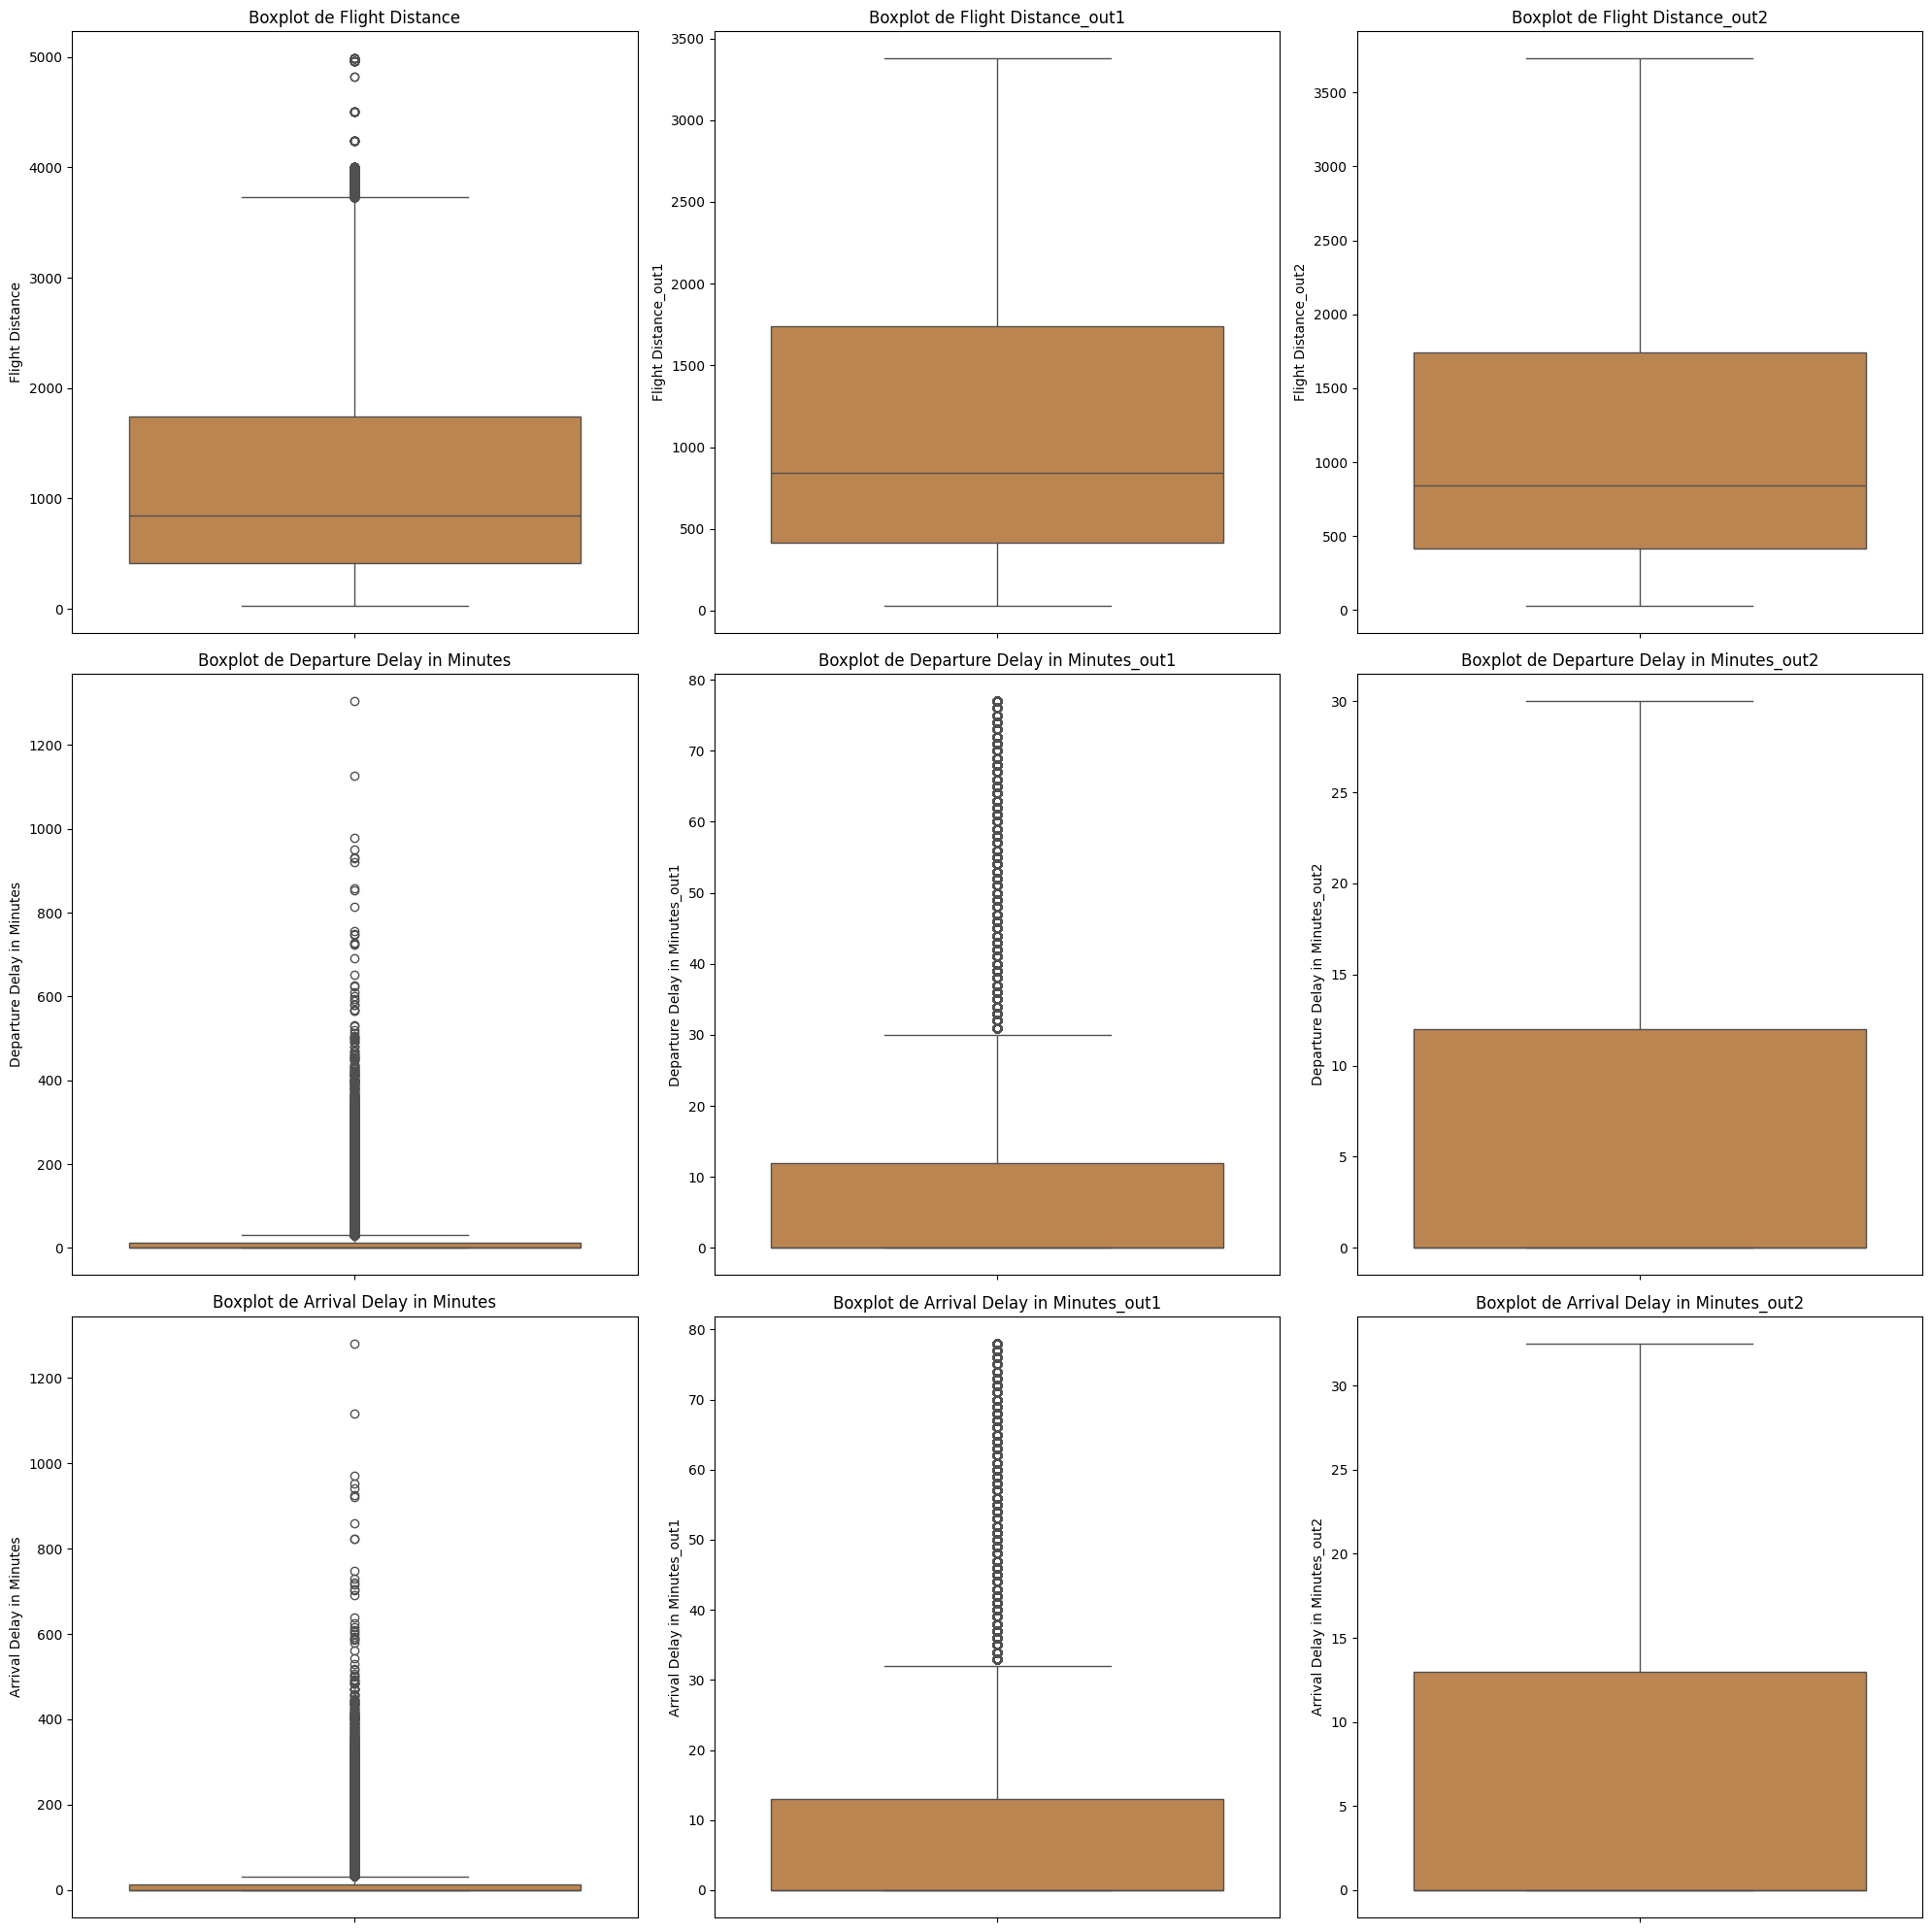

In [52]:
#boxplot de las variables numéricas
nrows, ncols =3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 20))

for i, col in enumerate(['Flight Distance','Flight Distance_out1','Flight Distance_out2',
                         'Departure Delay in Minutes','Departure Delay in Minutes_out1', 'Departure Delay in Minutes_out2',
                         'Arrival Delay in Minutes','Arrival Delay in Minutes_out1','Arrival Delay in Minutes_out2']):
    row = i // ncols
    col_idx = i % ncols
    sns.boxplot(y=col, data=df_outliers, ax=axes[row, col_idx], color='peru')
    axes[row, col_idx].set_title(f'Boxplot de {col}')
    axes[row, col_idx].set_ylabel(col)

for j in range(i + 1, nrows * ncols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()


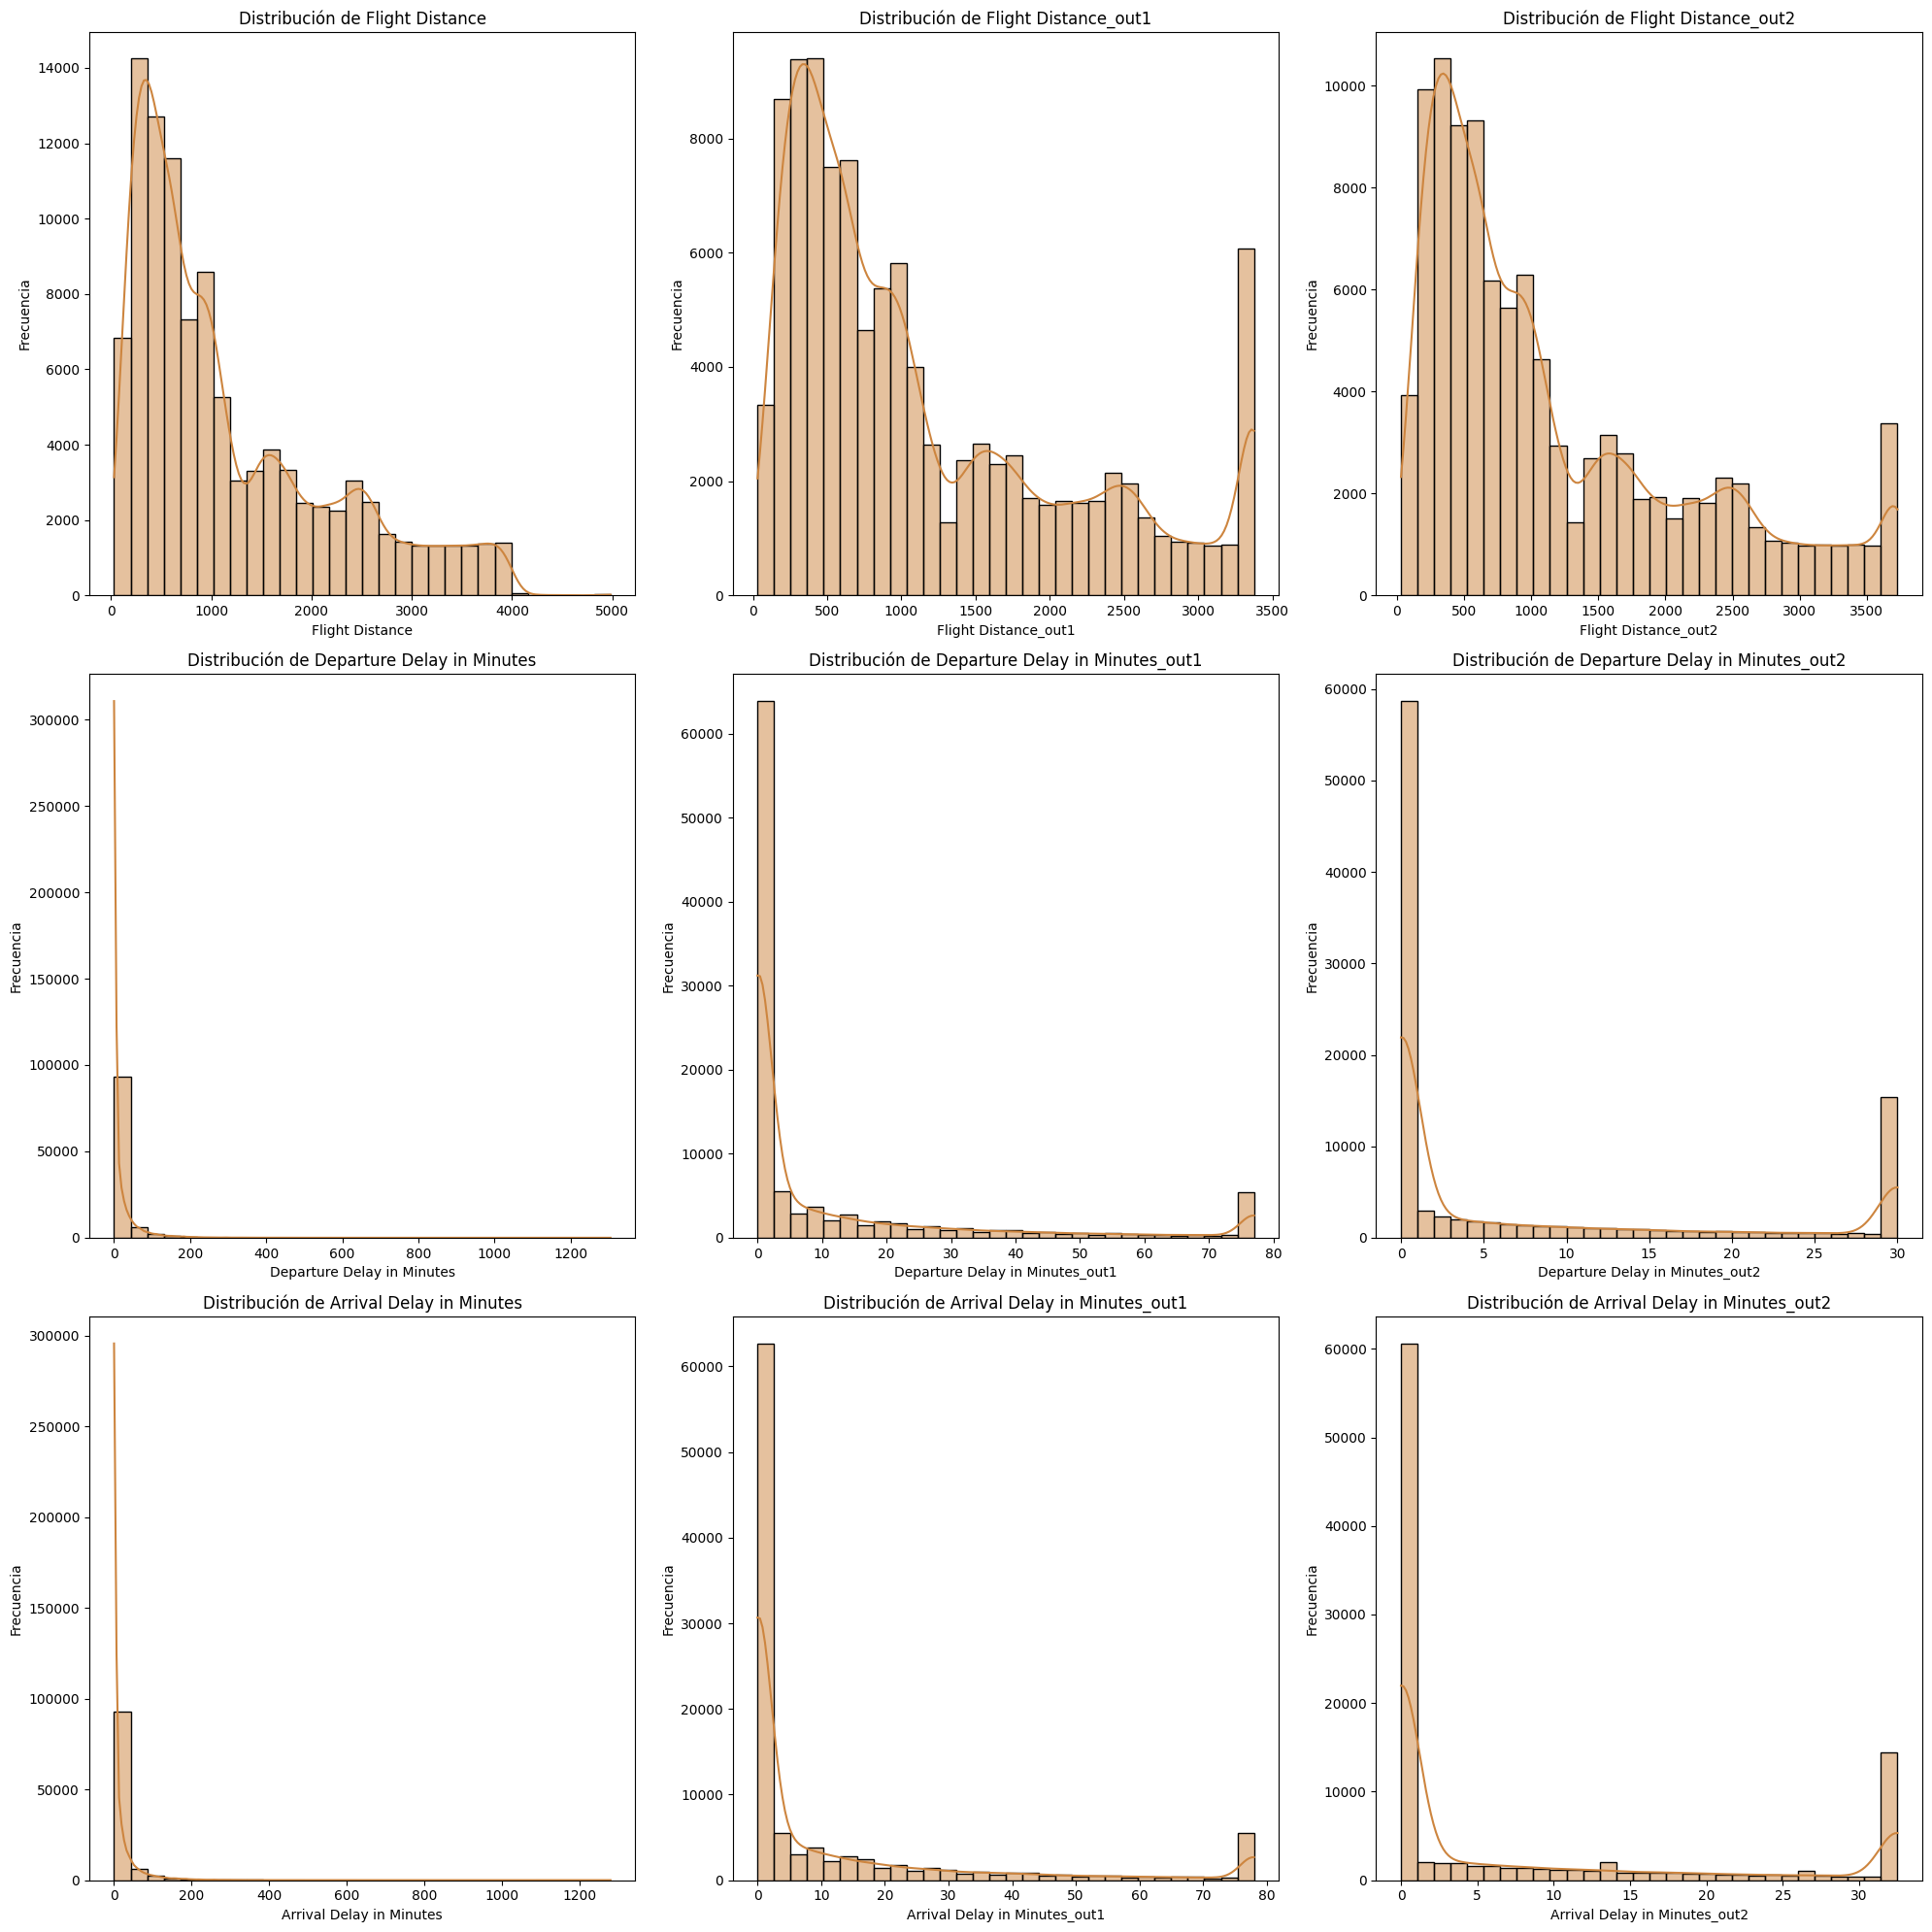

In [53]:
# Distribución variables numéricas discretas
nrows, ncols = 3, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 20))

for i, col in enumerate(['Flight Distance','Flight Distance_out1','Flight Distance_out2',
                         'Departure Delay in Minutes','Departure Delay in Minutes_out1', 'Departure Delay in Minutes_out2',
                         'Arrival Delay in Minutes','Arrival Delay in Minutes_out1','Arrival Delay in Minutes_out2']):
    row = i // ncols
    col_idx = i % ncols
    sns.histplot(df_outliers[col], kde=True, bins=30, ax=axes[row, col_idx], color='peru')
    axes[row, col_idx].set_title(f'Distribución de {col}')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Frecuencia')

for j in range(i + 1, nrows * ncols):
    fig.delaxes(axes.flatten()[j])
plt.tight_layout()
plt.show()

Decidimos capear al percentil 95 de la distribución. Esto se debe a que no queríamos cortar tanto la distribución en la demora en el arribo y en la llegada, ya que podrian influir en el target que el vuelo haya salido o llegado con muchos minutos de retraso.

In [54]:
for col in ['Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']:
    q95= df_train[col].quantile(0.95)
    df_train[col]= np.where(df_train[col]>q95, q95, df_train[col])
    df_test[col]= np.where(df_test[col]>q95, q95, df_test[col])

In [55]:
df_train.shape,df_test.shape

((103904, 27), (25976, 27))

ANALISIS DEL TARGET EN 2 DIMENSIONES:

Utilizamos dos técnicas de reducción de dimensionalidad: PCA y t-SNE, con la intención de detectar patrones o clusters.  

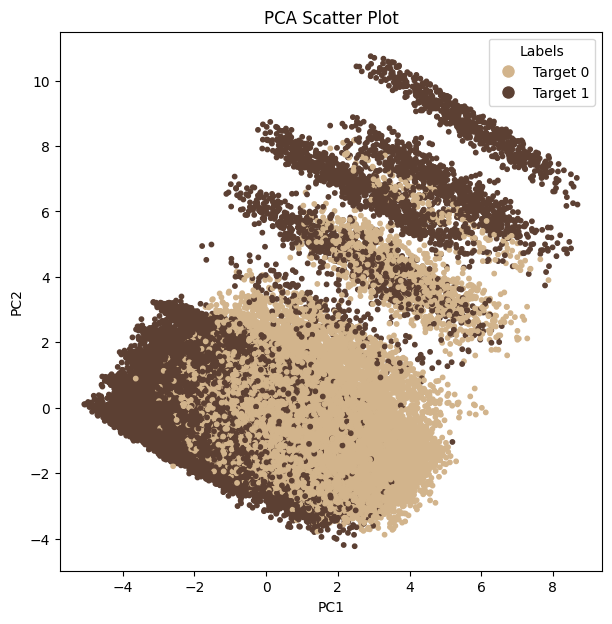

  Component  Explained Variance Ratio  Explained Variance
0       PC1                  0.163886            4.261086
1       PC2                  0.120147            3.123865


In [56]:
# Separamos las features del target
X = df_train.drop(columns='target')
y = df_train['target']

# Estandarizar las features
X_scaled = StandardScaler().fit_transform(X)

# Aplicar PCA con 2 componentes
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Crear un DataFrame con las componentes principales y el target
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['target'] = y

# Graficar los resultados
fig1 = plt.figure(figsize=(7, 7), facecolor='white')
ax = fig1.add_subplot(1, 1, 1)
ax.set_facecolor('white')
scatter = plt.scatter(df_pca.PC1, df_pca.PC2, c=y, marker='o', s=10, cmap=brown_palette)

unique_labels = np.unique(y)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10, linestyle='') for label in unique_labels]
plt.legend(handles=handles, labels=[f'Target {label}' for label in unique_labels], title='Labels')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Scatter Plot')
plt.show()

# Obtener la varianza explicada por cada componente
explained_variance_ratio = pca.explained_variance_ratio_
explained_variance = pca.explained_variance_

# Crear un DataFrame con la varianza explicada
variance_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(explained_variance_ratio))],
    'Explained Variance Ratio': explained_variance_ratio,
    'Explained Variance': explained_variance
})

# Mostrar el DataFrame con la varianza explicada
print(variance_df)


Con PCA vemos que con dos componentes solo captamos el 28% de la varianza.

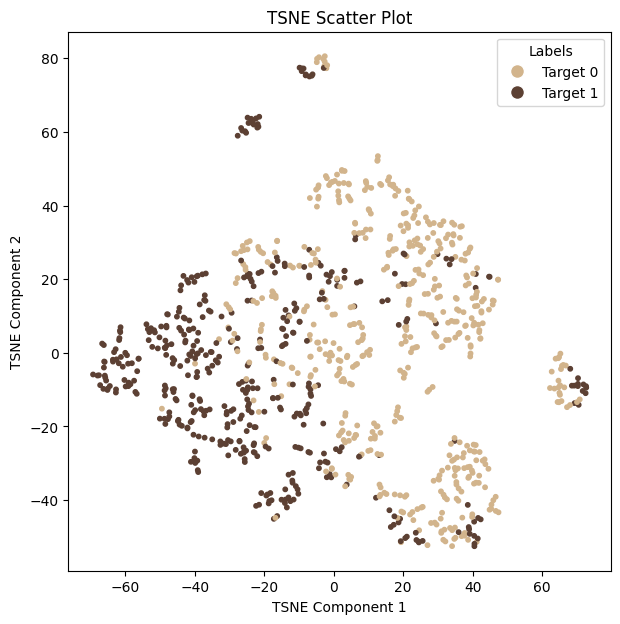

In [57]:
#Tomamos una muestra del dataset de train porque tsne demora mucho tiempo en correr.
sample = df_train.sample(1000)
X_sample=sample.drop(columns='target')
y_sample = sample['target']

#Escalamos las features
X_sample_scaled = StandardScaler().fit_transform(X_sample)

#Instanciamos TSNE con 2 componentes
tsne = TSNE(n_components=2, perplexity=10, random_state=42).fit_transform(X_sample_scaled)


fig1 = plt.figure(figsize=(7, 7), facecolor='white')
ax = fig1.add_subplot(1, 1, 1)
ax.set_facecolor('white')

# Scatter plot
scatter = plt.scatter(tsne[:, 0], tsne[:, 1], c=y_sample, marker='o', s=10, cmap=brown_palette)


unique_labels = np.unique(y_sample)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=scatter.cmap(scatter.norm(label)), markersize=10, linestyle='') for label in unique_labels]
plt.legend(handles=handles, labels=[f'Target {label}' for label in unique_labels], title='Labels')


plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.title('TSNE Scatter Plot')
plt.show()


En el gráfico de dispersión con las dos componentes de t-SNE, vemos que los clientes con target 1 se ubican en una región separable de los clientes con target 0.

CONCLUSION: evidentemente hay una relación no lineal entre los datos y el target esto hace que PCA no sea un buen método para detectar patrones, a diferencia de t-SNE que vemos bien marcados dos clusters diferentes.




SELECCION DE FEATURES

Lo primero que probamos es instanciar un modelo básico y revisar el feature importance. Esto nos permitiría eliminar features que no esperamos que sean predictivas en caso de tener alta dimensionalidad

In [58]:
# Separamos el dataset de train en las features y el target
X_train = df_train.drop(columns='target')
y_train = df_train['target']

# Instanciar el modelo de árbol de clasificación
clf = DecisionTreeClassifier(random_state=42)
# Entrenar el modelo
clf.fit(X_train, y_train)

# Obtener la importancia de las características
importances = clf.feature_importances_

# Crear un DataFrame para visualizar la importancia de las características
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

                                   Feature  Importance
8                          Online boarding    0.361072
21          Type of Travel_Personal Travel    0.150000
3                    Inflight wifi service    0.119409
22              Inflight wifi service_rta0    0.058525
10                  Inflight entertainment    0.047122
20         Customer Type_disloyal Customer    0.042199
14                         Checkin service    0.028618
0                                      Age    0.023865
2                          Flight Distance    0.023805
1                                    Class    0.019891
13                        Baggage handling    0.019841
6                            Gate location    0.019810
9                             Seat comfort    0.014834
15                        Inflight service    0.013662
16                             Cleanliness    0.010031
12                        Leg room service    0.009379
11                        On-board service    0.008715
18        

Considerando las variables que salen con poca importancia en el modelo y a priori parecen menos predictivas son 3 de los 4 flags que creamos para indicar que existen missings, el género, la facilidad para comprar online y la comida y la bebida. Sin embargo, cuando revisamos los bivariados, la comida y la bebida si mostraban tener una relación con el target.

Como otra alternativa de selección de features, probamos aplicar una regularización de Lasso a la regresión logística con diferentes valores de alfa, ya que esta regularización penaliza features que no aportan al modelo, llevandolas a un coeficiente de 0.

In [59]:
sc = StandardScaler()

X_train_sc = sc.fit_transform(X_train)

# Lista de valores alpha a probar
alpha_values =  [10, 100, 500, 1000]

results = []

for alpha in alpha_values:
    C = 1/alpha
    #entrenamos LR con diferentes valores de alpha
    model = LogisticRegression(penalty='l1', solver='liblinear', C=C, random_state=42)
    model.fit(X_train_sc, y_train)

    #contamos la cantidad de features con coeficiente cero
    zero_coef_count = np.sum(model.coef_[0] == 0)

    print(f'alpha: {alpha}')
    print(f'Cant. features con coeficiente cero: {zero_coef_count}')
    print(X_train.columns[model.coef_[0] == 0])
    print('\n')

alpha: 10
Cant. features con coeficiente cero: 0
Index([], dtype='object')


alpha: 100
Cant. features con coeficiente cero: 1
Index(['Departure Delay in Minutes'], dtype='object')


alpha: 500
Cant. features con coeficiente cero: 6
Index(['Age', 'Food and drink', 'Departure Delay in Minutes', 'Gender_Male',
       'Departure/Arrival time convenient_rta0',
       'Ease of Online booking_rta0'],
      dtype='object')


alpha: 1000
Cant. features con coeficiente cero: 8
Index(['Age', 'Ease of Online booking', 'Food and drink', 'Seat comfort',
       'Departure Delay in Minutes', 'Gender_Male',
       'Departure/Arrival time convenient_rta0',
       'Ease of Online booking_rta0'],
      dtype='object')




Con un alpha= 500, las variables que salen con coeficiente nulo, vemos que en su mayoría coinciden con las features que salieron sin importancia en el árbol: el género, la comida y bebida y dos de los flags de que el servicio tenía el voto sin responder.

### MODELADO

Primero instanciamos algunos modelos baselines (sin optimización de hiperparametros). Una vez que tenemos los resultados, comparamos e identificamos el modelo que performa mejor y lo optimizamos.

In [60]:
X_train = df_train.drop(['target'], axis=1)
y_train = df_train['target']

X_test = df_test.drop(['target'], axis=1)
y_test = df_test['target']

In [61]:
df_metrics = pd.DataFrame(columns=['Modelo','AUC train','AUC test','Accuracy','Precision','Recall','F1 Score'])

In [62]:
sc = StandardScaler()

X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [63]:
lr = LogisticRegression(random_state=42)
knn = KNeighborsClassifier(n_neighbors=15)
tree = DecisionTreeClassifier(max_depth=10, min_samples_leaf=15, random_state=42) #Hiperparametros para que no haga tanto overfitting --> si lo dejamos con los hiperparametros por default va a crecer hasta predecir cada observacion correctamente.
lgbm_model = lgbm.LGBMClassifier(random_state=42)
xgb_model = xgb.XGBClassifier(random_state=42)

In [64]:
lr.fit(X_train_sc, y_train)

y_pred_train_prob = lr.predict_proba(X_train_sc)[:, 1]
y_pred = lr.predict(X_test_sc)
y_pred_prob = lr.predict_proba(X_test_sc)[:, 1]


auc_score_train = roc_auc_score(y_train, y_pred_train_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

model_name = 'LogisticRegression'
df_metrics.loc[len(df_metrics)] = [model_name, auc_score_train, auc_score, accuracy, precision, recall, f1]
df_metrics

,Modelo,AUC train,AUC test,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.965247,0.963323,0.902179,0.891098,0.88427,0.887671


In [65]:
# Obtenemos los coeficientes de la regresion logistica
coeficientes = lr.coef_[0]
variables = X_train.columns


df_coeficientes = pd.DataFrame({
    'Variable': variables,
    'Coeficiente': coeficientes
})


df_coeficientes.loc[len(df_coeficientes)] = ['Intercepto',  lr.intercept_[0]]


display(df_coeficientes.sort_values(by='Coeficiente'))

,Variable,Coeficiente
21,Type of Travel_Personal Travel,-1.581024
20,Customer Type_disloyal Customer,-1.033901
26,Intercepto,-0.805338
4,Departure/Arrival time convenient,-0.550383
18,Arrival Delay in Minutes,-0.326700
6,Gate location,-0.311458
23,Departure/Arrival time convenient_rta0,-0.176567
7,Food and drink,-0.076957
0,Age,-0.042287
19,Gender_Male,0.030865


Revisando los coeficientes de la Regresión Logística, vemos:

Coeficientes negativos para 'Type of Travel_Personal Travel' y 'Customer Type_disloyal Customer'. Lo que indica que a medida que aumenta la variable, disminuye la satisfacción del cliente.

Coeficientes positivos para: 'Inflight wifi service', 'Online boarding' y 'Inflight wifi service_rta0'. Lo que indica que un valores más altos de la variable impactan positivamente en el target, es decir, que afecta positivamente en la satisfacción del cliente.



In [66]:
knn.fit(X_train_sc, y_train)

y_pred_train_prob = knn.predict_proba(X_train_sc)[:, 1]
y_pred = knn.predict(X_test_sc)
y_pred_prob = knn.predict_proba(X_test_sc)[:, 1]


auc_score_train = roc_auc_score(y_train, y_pred_train_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

model_name = 'KNN'
df_metrics.loc[len(df_metrics)] = [model_name, auc_score_train, auc_score, accuracy, precision, recall, f1]
df_metrics

,Modelo,AUC train,AUC test,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.965247,0.963323,0.902179,0.891098,0.884270,0.887671
1,KNN,0.990524,0.982908,0.936518,0.956878,0.895103,0.924960


In [67]:
tree.fit(X_train, y_train)

y_pred_train_prob = tree.predict_proba(X_train)[:, 1]
y_pred = tree.predict(X_test)
y_pred_prob = tree.predict_proba(X_test)[:, 1]

auc_score_train = roc_auc_score(y_train, y_pred_train_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

model_name = 'DecisionTreeClassifier'
df_metrics.loc[len(df_metrics)] = [model_name, auc_score_train, auc_score, accuracy, precision, recall, f1]
df_metrics

,Modelo,AUC train,AUC test,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.965247,0.963323,0.902179,0.891098,0.884270,0.887671
1,KNN,0.990524,0.982908,0.936518,0.956878,0.895103,0.924960
2,DecisionTreeClassifier,0.990058,0.987552,0.945527,0.956462,0.917122,0.936379


In [68]:
lgbm_model.fit(X_train, y_train)

y_pred_train_prob = lgbm_model.predict_proba(X_train)[:, 1]
y_pred = lgbm_model.predict(X_test)
y_pred_prob = lgbm_model.predict_proba(X_test)[:, 1]

auc_score_train = roc_auc_score(y_train, y_pred_train_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

model_name = 'LGBMClassifier'
df_metrics.loc[len(df_metrics)] = [model_name, auc_score_train, auc_score, accuracy, precision, recall, f1]
df_metrics

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 45074, number of negative: 58830
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012796 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 589
[LightGBM] [Info] Number of data points in the train set: 103904, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.433804 -> initscore=-0.266346
[LightGBM] [Info] Start training from score -0.266346


,Modelo,AUC train,AUC test,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.965247,0.963323,0.902179,0.891098,0.884270,0.887671
1,KNN,0.990524,0.982908,0.936518,0.956878,0.895103,0.924960
2,DecisionTreeClassifier,0.990058,0.987552,0.945527,0.956462,0.917122,0.936379
3,LGBMClassifier,0.995987,0.995029,0.963389,0.977772,0.937555,0.957241


In [69]:
xgb_model.fit(X_train, y_train)

y_pred_train_prob = xgb_model.predict_proba(X_train)[:, 1]
y_pred = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

auc_score_train = roc_auc_score(y_train, y_pred_train_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

model_name = 'XGBClassifier'
df_metrics.loc[len(df_metrics)] = [model_name, auc_score_train, auc_score, accuracy, precision, recall, f1]
df_metrics

,Modelo,AUC train,AUC test,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.965247,0.963323,0.902179,0.891098,0.884270,0.887671
1,KNN,0.990524,0.982908,0.936518,0.956878,0.895103,0.924960
2,DecisionTreeClassifier,0.990058,0.987552,0.945527,0.956462,0.917122,0.936379
3,LGBMClassifier,0.995987,0.995029,0.963389,0.977772,0.937555,0.957241
4,XGBClassifier,0.998204,0.995021,0.962619,0.973634,0.939933,0.956487


Como se puede observar, sin ajustar hiperparámetros, todos los modelos performan demasiado bien (evidentemente las features que tenemos son altamente predictvas para nuestro target).

El modelo de regresión logística es el que peor performa en este caso (los modelos de ensambles le ganan por 3 puntos). Seguido por el KNN y el árbol de clasificación.

El modelo que mejor perfoma es el XGBClassifier. A continuación vamos a realizar una optimización de los hiperparámetros.

OPTIMIZACION DE HIPERPARAMETROS

In [70]:
classifier_xgb = xgb.XGBClassifier(random_state=42)


hyperparams = {
    "n_estimators": np.arange(1,10),  # Number of parallel trees constructed during each iteration. Default to 1.
    "max_depth": np.arange(3, 12),  # Maximum tree depth for base learners. Default to 6.
    "learning_rate": np.arange(0.1, 1.1, 0.05).tolist(),  # learning rate. Default to 0.3.
    "reg_alpha": np.arange(0, 0.1, 0.01).tolist(), #L1 regularization term on weights. Default to 0.
    "colsample_bytree": [0.5, 0.7, 1.0]  #Is the subsample ratio of columns when constructing each tree. Default 1.
}

random_search = RandomizedSearchCV(classifier_xgb,
                                    hyperparams,
                                    n_iter=50,  # Number of parameter settings that are sampled.
                                    scoring='f1',
                                    cv=3,
                                    n_jobs=-1,
                                    random_state=42)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                                          0.6000000000000002,
                                                          0.6500000000000001,
                                                          0.7000000000000002,
                                                          0.7500000000000002,
                                                          0.8000000000000002,
                                                          0.8500000000000002,
                                                          0.9000000000000002,
                                                          0.9500000000000003,
                                                          1.0000000000000004,
                                                          1.0500000000000003],
                                        'max_depth': array([ 3,  4,  5,  6,  7,  8,  9, 10, 11]),
                                        'n_estimators': array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
                                        'reg_alpha': [0.0, 0.01, 0.02, 0.03,
                                                      0.04, 0.05, 0.06, 0.07,
                                                      0.08, 0.09]},
                   random_state=42, scoring='f1')

In [71]:
random_search.best_params_

{'reg_alpha': 0.07,
 'n_estimators': 9,
 'max_depth': 10,
 'learning_rate': 0.40000000000000013,
 'colsample_bytree': 0.7}

In [72]:
best_xgb_grid = xgb.XGBClassifier(**random_search.best_params_)
best_xgb_grid.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.40000000000000013,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=9, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [73]:
auc_score_train = roc_auc_score(y_train,best_xgb_grid.predict_proba(X_train)[:, 1])
print(auc_score_train)
auc_score = roc_auc_score(y_test, best_xgb_grid.predict_proba(X_test)[:, 1])
print(auc_score)
accuracy = accuracy_score(y_test, best_xgb_grid.predict(X_test))
print(accuracy)

0.9964837019744841
0.9941598657853078
0.9612719433323067


MATRIZ DE CONFUSION

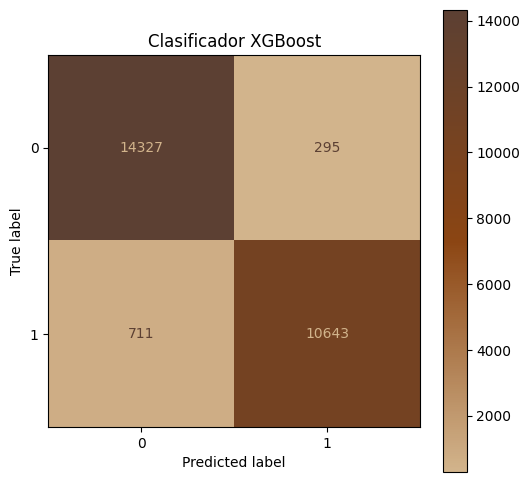

In [74]:
# Calculamos la matriz de confusión con threshold default (0.5)
cm_final_model = confusion_matrix(y_test, best_xgb_grid.predict(X_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_final_model)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax, cmap=brown_palette)
ax.set_title("Clasificador XGBoost");

In [75]:
# Midamos la sensibilidad y especificidad
print("Clasificador XGBoost")
P = np.sum(cm_final_model[1, :])
N = np.sum(cm_final_model[0, :])
TP = cm_final_model[1, 1]
TN = cm_final_model[0, 0]
TPR = TP/P
TNR = TN/N
print(f"Sensibilidad: {TP/P}")
print(f"Especificidad: {TN/N}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precision: {precision_score(y_test, best_xgb_grid.predict(X_test), zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, best_xgb_grid.predict(X_test), zero_division=0)}")
print(f"F1-score: {f1_score(y_test, best_xgb_grid.predict(X_test), zero_division=0)}")

Clasificador XGBoost
Sensibilidad: 0.9373788973049145
Especificidad: 0.9798249213513883
Exactitud balanceada: 0.9586019093281515
Precision: 0.9730298043518011
Recuperación: 0.9373788973049145
F1-score: 0.9548717028530413


In [76]:
#Calculamos el threshold que maximice el F1-score
thresholds = np.arange(0.0, 1.0, 0.01)

best_threshold = 0.0
best_f1 = 0.0

y_probs = best_xgb_grid.predict_proba(X_test)[:, 1]

for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred)

    # Mejorar el umbral si encontramos una mejor F1-score
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f'Mejor umbral: {best_threshold}, Mejor F1-score: {best_f1}')

Mejor umbral: 0.47000000000000003, Mejor F1-score: 0.9553279971381299


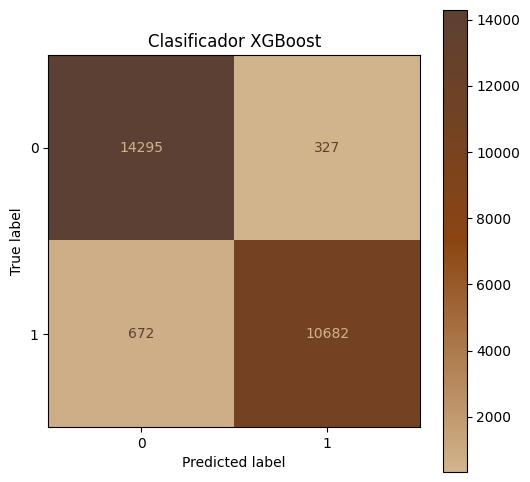

In [77]:
# Calculamos la matriz de confusion con el threshold optimo
probabilidades = best_xgb_grid.predict_proba(X_test)

umbral = best_threshold
y_pred = (probabilidades[:, 1] >= best_threshold).astype(int)

cm_final_model = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_final_model)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax, cmap=brown_palette)
ax.set_title("Clasificador XGBoost");

In [78]:
# Midamos la sensibilidad y especificidad
print("Clasificador XGBoost")
P = np.sum(cm_final_model[1, :])
N = np.sum(cm_final_model[0, :])
TP = cm_final_model[1, 1]
TN = cm_final_model[0, 0]
TPR = TP/P
TNR = TN/N
print(f"Sensibilidad: {TP/P}")
print(f"Especificidad: {TN/N}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, y_pred, zero_division=0)}")
print(f"F1-score: {f1_score(y_test,y_pred, zero_division=0)}")

Clasificador XGBoost
Sensibilidad: 0.9408138101109741
Especificidad: 0.9776364382437424
Exactitud balanceada: 0.9592251241773582
Precision: 0.9702970297029703
Recuperación: 0.9408138101109741
F1-score: 0.9553279971381299


Ajustando el threshold que maximice el F1-score para hacer las predicciones del modelo, logramos reducir la cantidad de falsos negativos.

FEATURE IMPORTANCE

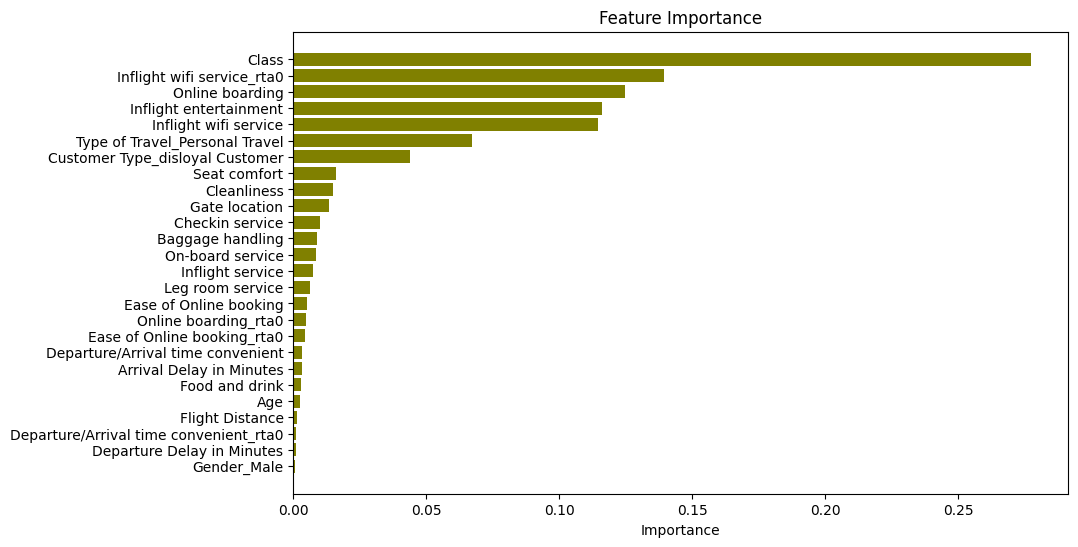

In [79]:
importance = best_xgb_grid.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})


feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)


plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='olive')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

Observando el feature importance del modelo optimizado, vemos que las 5 features más relevantes para predecir el target son:
* Class
* Inflight wifi service rta_0
* Online boarding
* Inflight entertainment
* Inflight wifi service

INTERPRETABILIDAD

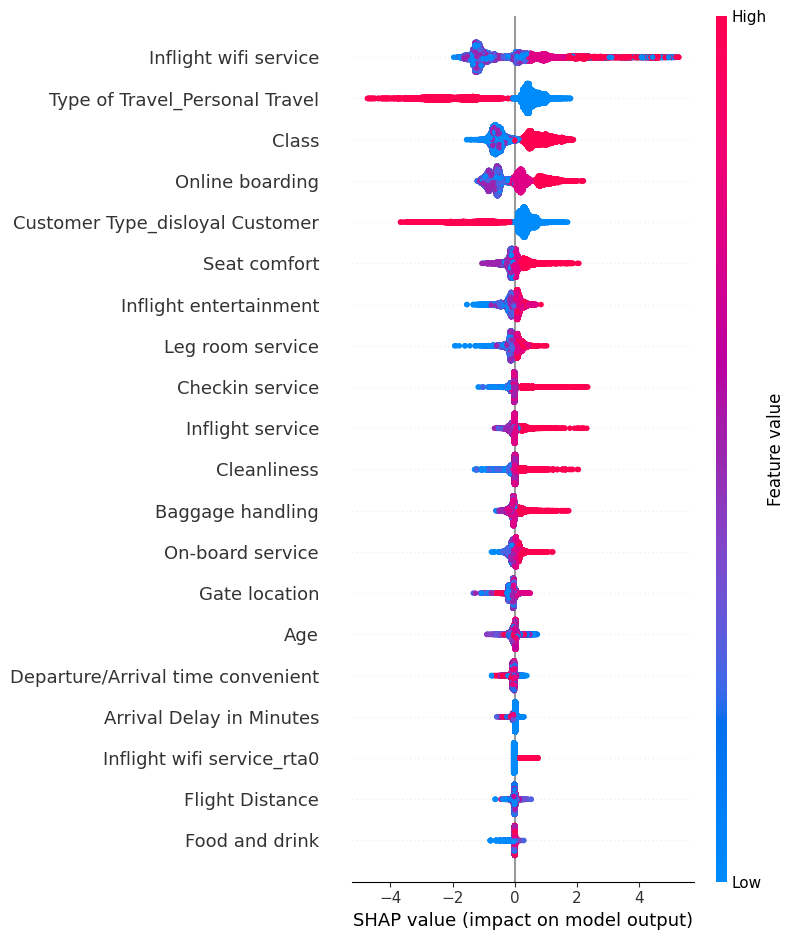

In [80]:
# Crear el objeto explainer
explainer = shap.Explainer(best_xgb_grid)

# Calcular los valores SHAP para el conjunto de prueba
shap_values = explainer(X_test)

# Visualizar los valores SHAP con un gráfico de resúmenes
shap.summary_plot(shap_values, X_test)

El gráfico de SHAP values muestra la contribución de las variables a las predicciones de un modelo y ayuda a entender rápidamente cuáles variables son más influyentes y cómo afectan las decisiones del modelo.

En este gráfico, los colores juegan un papel importante: los puntos en rojo representan valores más altos, mientras que los puntos en azul indican valores más bajos de la variable.

El eje X refleja la magnitud y la dirección del efecto que tiene cada característica en la predicción: los valores hacia la derecha indican que la característica aporta positivamente al target, mientras que los valores hacia la izquierda sugieren un aporte negativo.

En nuestro caso: vemos que valores altos de la variable 'Inflight wifi service' aportan positivamente al target. Lo contrario vemos con la variable 'Type of Travel-Personal Travel', a valores menores (0: pasajeros que viajan por trabajo) hay un aporte positivo al target.

CONCLUSIONES

* La variable 'Clase' resultó ser la más importante en el modelo.
* El servicio de wifi a bordo también es un servicio que evidentemente los pasajeros valoran, junto con el entretenimiento y el embarque online.
* Antes de empezar el análisis, teníamos como hipotesis que las variables más importantes iban a ser la comida, la comodidad del asiento, el espacio para las piernas y la demora en salir y llegar, pero esto no se verificó en los resultados de los modelos.
* Respecto de la AUC ROC tan alta que tenemos, entendemos que no es un resultado normal ni deseable (muy bueno para ser cierto), pero evidentemente el dataset tiene features que son altamente predictoras.

#### BONUS TRACK:
Como tenemos una performance tan alta, vamos a intentamos entrenar un modelo eliminando todas las features de nivel de satisfacción y evaluar los resultados.

In [81]:
X_train = df_train.drop(['Inflight wifi service',
 'Departure/Arrival time convenient',
 'Ease of Online booking',
 'Gate location',
 'Food and drink',
 'Online boarding',
 'Seat comfort',
 'Inflight entertainment',
 'On-board service',
 'Leg room service',
 'Baggage handling',
 'Checkin service',
 'Inflight service',
 'Cleanliness',
 'Inflight wifi service_rta0',
 'Departure/Arrival time convenient_rta0',
 'Ease of Online booking_rta0',
 'Online boarding_rta0',
 'target'], axis=1)
y_train = df_train['target']

X_test = df_test.drop(['Inflight wifi service',
 'Departure/Arrival time convenient',
 'Ease of Online booking',
 'Gate location',
 'Food and drink',
 'Online boarding',
 'Seat comfort',
 'Inflight entertainment',
 'On-board service',
 'Leg room service',
 'Baggage handling',
 'Checkin service',
 'Inflight service',
 'Cleanliness',
 'Inflight wifi service_rta0',
 'Departure/Arrival time convenient_rta0',
 'Ease of Online booking_rta0',
 'Online boarding_rta0',
 'target'], axis=1)
y_test = df_test['target']

In [82]:
df_metrics = pd.DataFrame(columns=['Modelo','AUC train','AUC test','Accuracy','Precision','Recall','F1 Score'])

In [83]:
sc = StandardScaler()

X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

In [84]:
lr = LogisticRegression(random_state=42)
knn = KNeighborsClassifier(n_neighbors=15)
tree = DecisionTreeClassifier(max_depth=10, min_samples_leaf=15, random_state=42) #Hiperparametros para que no haga tanto overfitting --> si lo dejamos con los hiperparametros por default va a crecer hasta predecir cada observacion correctamente.
lgbm_model = lgbm.LGBMClassifier(random_state=42)
xgb_model = xgb.XGBClassifier(random_state=42)

In [85]:
lr.fit(X_train_sc, y_train)

y_pred_train_prob = lr.predict_proba(X_train_sc)[:, 1]
y_pred = lr.predict(X_test_sc)
y_pred_prob = lr.predict_proba(X_test_sc)[:, 1]


auc_score_train = roc_auc_score(y_train, y_pred_train_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

model_name = 'LogisticRegression'
df_metrics.loc[len(df_metrics)] = [model_name, auc_score_train, auc_score, accuracy, precision, recall, f1]
df_metrics

,Modelo,AUC train,AUC test,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.843212,0.84035,0.785071,0.733852,0.797516,0.764361


In [86]:
# Obtenemos los coeficientes de la regresion logistica
coeficientes = lr.coef_[0]
variables = X_train.columns


df_coeficientes = pd.DataFrame({
    'Variable': variables,
    'Coeficiente': coeficientes
})


df_coeficientes.loc[len(df_coeficientes)] = ['Intercepto',  lr.intercept_[0]]


display(df_coeficientes.sort_values(by='Coeficiente'))

,Variable,Coeficiente
7,Type of Travel_Personal Travel,-1.077651
6,Customer Type_disloyal Customer,-0.645017
8,Intercepto,-0.459831
4,Arrival Delay in Minutes,-0.327668
0,Age,0.001952
5,Gender_Male,0.015834
2,Flight Distance,0.035707
3,Departure Delay in Minutes,0.091103
1,Class,0.600255


Revisando los coeficientes de la Regresión Logística, vemos:

Coeficientes negativos para 'Type of Travel_Personal Travel' y 'Customer Type_disloyal Customer'. Lo que indica que a medida que aumenta la variable, disminuye la satisfacción del cliente. Es decir, si el viaje es de motivo personal, se espera que el cliente este mas insatisfecho que si no lo es, y si el cliente no es leal, lo mismo. También la demora en el arribo tiene un coeficiente negativo, esto implica que a más se demore en avion en la llegada, más desconforme estará el usuario.

Coeficientes positivos para: 'Class', 'Departure Delay in Minutes' y 'Flight Distance'. Lo que indica que un valores más altos de la variable impactan positivamente en el target, es decir, que afecta positivamente en la satisfacción del cliente.

In [87]:
knn.fit(X_train_sc, y_train)

y_pred_train_prob = knn.predict_proba(X_train_sc)[:, 1]
y_pred = knn.predict(X_test_sc)
y_pred_prob = knn.predict_proba(X_test_sc)[:, 1]


auc_score_train = roc_auc_score(y_train, y_pred_train_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

model_name = 'KNN'
df_metrics.loc[len(df_metrics)] = [model_name, auc_score_train, auc_score, accuracy, precision, recall, f1]
df_metrics

,Modelo,AUC train,AUC test,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.843212,0.840350,0.785071,0.733852,0.797516,0.764361
1,KNN,0.888388,0.850363,0.794541,0.756370,0.781751,0.768851


In [88]:
tree.fit(X_train, y_train)

y_pred_train_prob = tree.predict_proba(X_train)[:, 1]
y_pred = tree.predict(X_test)
y_pred_prob = tree.predict_proba(X_test)[:, 1]

auc_score_train = roc_auc_score(y_train, y_pred_train_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

model_name = 'DecisionTreeClassifier'
df_metrics.loc[len(df_metrics)] = [model_name, auc_score_train, auc_score, accuracy, precision, recall, f1]
df_metrics

,Modelo,AUC train,AUC test,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.843212,0.840350,0.785071,0.733852,0.797516,0.764361
1,KNN,0.888388,0.850363,0.794541,0.756370,0.781751,0.768851
2,DecisionTreeClassifier,0.878369,0.862916,0.800470,0.767908,0.778933,0.773381


In [89]:
lgbm_model.fit(X_train, y_train)

y_pred_train_prob = lgbm_model.predict_proba(X_train)[:, 1]
y_pred = lgbm_model.predict(X_test)
y_pred_prob = lgbm_model.predict_proba(X_test)[:, 1]

auc_score_train = roc_auc_score(y_train, y_pred_train_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

model_name = 'LGBMClassifier'
df_metrics.loc[len(df_metrics)] = [model_name, auc_score_train, auc_score, accuracy, precision, recall, f1]
df_metrics

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 45074, number of negative: 58830
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007514 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 497
[LightGBM] [Info] Number of data points in the train set: 103904, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.433804 -> initscore=-0.266346
[LightGBM] [Info] Start training from score -0.266346


,Modelo,AUC train,AUC test,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.843212,0.840350,0.785071,0.733852,0.797516,0.764361
1,KNN,0.888388,0.850363,0.794541,0.756370,0.781751,0.768851
2,DecisionTreeClassifier,0.878369,0.862916,0.800470,0.767908,0.778933,0.773381
3,LGBMClassifier,0.879391,0.867882,0.805782,0.769869,0.792584,0.781061


In [90]:
xgb_model.fit(X_train, y_train)

y_pred_train_prob = xgb_model.predict_proba(X_train)[:, 1]
y_pred = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

auc_score_train = roc_auc_score(y_train, y_pred_train_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

model_name = 'XGBClassifier'
df_metrics.loc[len(df_metrics)] = [model_name, auc_score_train, auc_score, accuracy, precision, recall, f1]
df_metrics

,Modelo,AUC train,AUC test,Accuracy,Precision,Recall,F1 Score
0,LogisticRegression,0.843212,0.840350,0.785071,0.733852,0.797516,0.764361
1,KNN,0.888388,0.850363,0.794541,0.756370,0.781751,0.768851
2,DecisionTreeClassifier,0.878369,0.862916,0.800470,0.767908,0.778933,0.773381
3,LGBMClassifier,0.879391,0.867882,0.805782,0.769869,0.792584,0.781061
4,XGBClassifier,0.892687,0.864245,0.800778,0.765946,0.783689,0.774716


Como se puede observar, sin ajustar hiperparámetros y con muy poquitas features, todos los modelos performan bien (evidentemente las features que tenemos son muy predictvas para nuestro target).

El modelo de regresión logística es el que peor performa en este caso (los modelos de ensambles le ganan por 2 puntos). Seguido por el KNN y el árbol de clasificación.

El modelo que mejor perfoma en test es el LightGBM pero el que mejor performa en train es el XGBClassifier (y que se observa que está haciendo cierto overfitting). A continuación vamos a realizar una optimización de los hiperparámetros.

OPTIMIZACION DE HIPERPARAMETROS

In [91]:
classifier_xgb = xgb.XGBClassifier(random_state=42)


hyperparams = {
    "n_estimators": np.arange(1,10),  # Number of parallel trees constructed during each iteration. Default to 1.
    "max_depth": np.arange(3, 12),  # Maximum tree depth for base learners. Default to 6.
    "learning_rate": np.arange(0.1, 1.1, 0.05).tolist(),  # learning rate. Default to 0.3.
    "reg_alpha": np.arange(0, 0.1, 0.01).tolist(), #L1 regularization term on weights. Default to 0.
    "colsample_bytree": [0.5, 0.7, 1.0]  #Is the subsample ratio of columns when constructing each tree. Default 1.
}

random_search = RandomizedSearchCV(classifier_xgb,
                                    hyperparams,
                                    n_iter=50,  # Number of parameter settings that are sampled.
                                    scoring='f1',
                                    cv=3,
                                    n_jobs=-1,
                                    random_state=42)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                                          0.6000000000000002,
                                                          0.6500000000000001,
                                                          0.7000000000000002,
                                                          0.7500000000000002,
                                                          0.8000000000000002,
                                                          0.8500000000000002,
                                                          0.9000000000000002,
                                                          0.9500000000000003,
                                                          1.0000000000000004,
                                                          1.0500000000000003],
                                        'max_depth': array([ 3,  4,  5,  6,  7,  8,  9, 10, 11]),
                                        'n_estimators': array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
                                        'reg_alpha': [0.0, 0.01, 0.02, 0.03,
                                                      0.04, 0.05, 0.06, 0.07,
                                                      0.08, 0.09]},
                   random_state=42, scoring='f1')

In [92]:
random_search.best_params_

{'reg_alpha': 0.03,
 'n_estimators': 5,
 'max_depth': 4,
 'learning_rate': 0.30000000000000004,
 'colsample_bytree': 1.0}

In [93]:
best_xgb_grid = xgb.XGBClassifier(**random_search.best_params_)
best_xgb_grid.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.30000000000000004,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=5, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [94]:
auc_score_train = roc_auc_score(y_train,best_xgb_grid.predict_proba(X_train)[:, 1])
print(auc_score_train)
auc_score = roc_auc_score(y_test, best_xgb_grid.predict_proba(X_test)[:, 1])
print(auc_score)
accuracy = accuracy_score(y_test, best_xgb_grid.predict(X_test))
print(accuracy)

0.8653956344408984
0.8620429949518542
0.8027024946104097


Como podemos notar, al haber aplicado el tunning de hiperparametros redujimos el overfitting que habia entre train y test.

MATRIZ DE CONFUSION

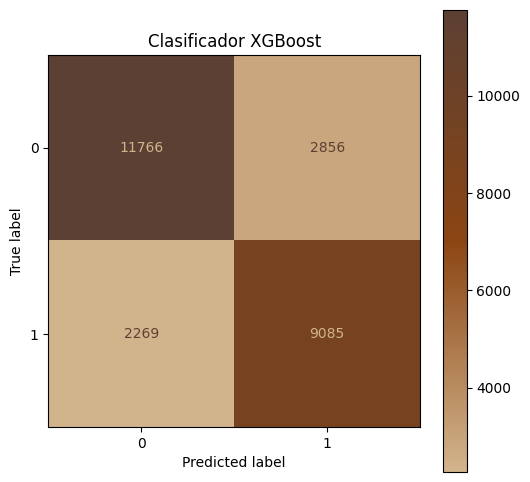

In [95]:
# Calculamos la matriz de confusión con threshold default (0.5)
cm_final_model = confusion_matrix(y_test, best_xgb_grid.predict(X_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm_final_model)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax, cmap=brown_palette)
ax.set_title("Clasificador XGBoost");

In [96]:
# Midamos la sensibilidad y especificidad
print("Clasificador XGBoost")
P = np.sum(cm_final_model[1, :])
N = np.sum(cm_final_model[0, :])
TP = cm_final_model[1, 1]
TN = cm_final_model[0, 0]
TPR = TP/P
TNR = TN/N
print(f"Sensibilidad: {TP/P}")
print(f"Especificidad: {TN/N}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precision: {precision_score(y_test, best_xgb_grid.predict(X_test), zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, best_xgb_grid.predict(X_test), zero_division=0)}")
print(f"F1-score: {f1_score(y_test, best_xgb_grid.predict(X_test), zero_division=0)}")

Clasificador XGBoost
Sensibilidad: 0.8001585344372028
Especificidad: 0.8046778826425933
Exactitud balanceada: 0.8024182085398981
Precision: 0.7608240515869693
Recuperación: 0.8001585344372028
F1-score: 0.7799957072333119


In [97]:
#Calculamos el threshold que maximice el F1-score
thresholds = np.arange(0.0, 1.0, 0.01)

best_threshold = 0.0
best_f1 = 0.0

y_probs = best_xgb_grid.predict_proba(X_test)[:, 1]

for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred)

    # Mejorar el umbral si encontramos una mejor F1-score
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f'Mejor umbral: {best_threshold}, Mejor F1-score: {best_f1}')

Mejor umbral: 0.45, Mejor F1-score: 0.7821271239773442


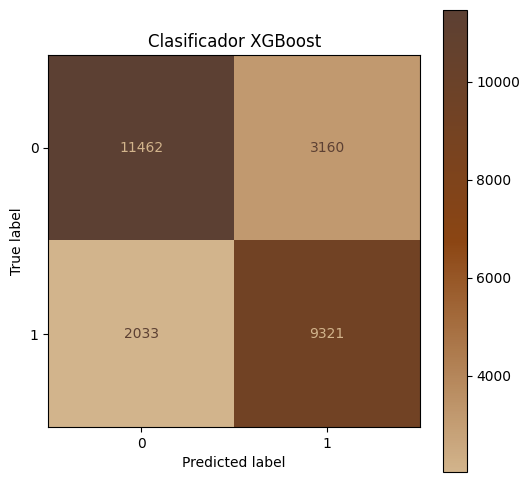

In [98]:
# Calculamos la matriz de confusion con el threshold optimo
probabilidades = best_xgb_grid.predict_proba(X_test)

umbral = best_threshold
y_pred = (probabilidades[:, 1] >= best_threshold).astype(int)

cm_final_model = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_final_model)

fig, ax = plt.subplots(figsize=(6,6))
ax.grid(False)
disp.plot(ax=ax, cmap=brown_palette)
ax.set_title("Clasificador XGBoost");

In [99]:
# Midamos la sensibilidad y especificidad
print("Clasificador XGBoost")
P = np.sum(cm_final_model[1, :])
N = np.sum(cm_final_model[0, :])
TP = cm_final_model[1, 1]
TN = cm_final_model[0, 0]
TPR = TP/P
TNR = TN/N
print(f"Sensibilidad: {TP/P}")
print(f"Especificidad: {TN/N}")
print(f"Exactitud balanceada: {(TPR + TNR)/2}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0)}")
print(f"Recuperación: {recall_score(y_test, y_pred, zero_division=0)}")
print(f"F1-score: {f1_score(y_test,y_pred, zero_division=0)}")

Clasificador XGBoost
Sensibilidad: 0.8209441606482297
Especificidad: 0.7838872931199562
Exactitud balanceada: 0.802415726884093
Precision: 0.7468151590417434
Recuperación: 0.8209441606482297
F1-score: 0.7821271239773442


Ajustando el threshold que maximice el F1-score para hacer las predicciones del modelo, logramos reducir la cantidad de falsos negativos.

FEATURE IMPORTANCE

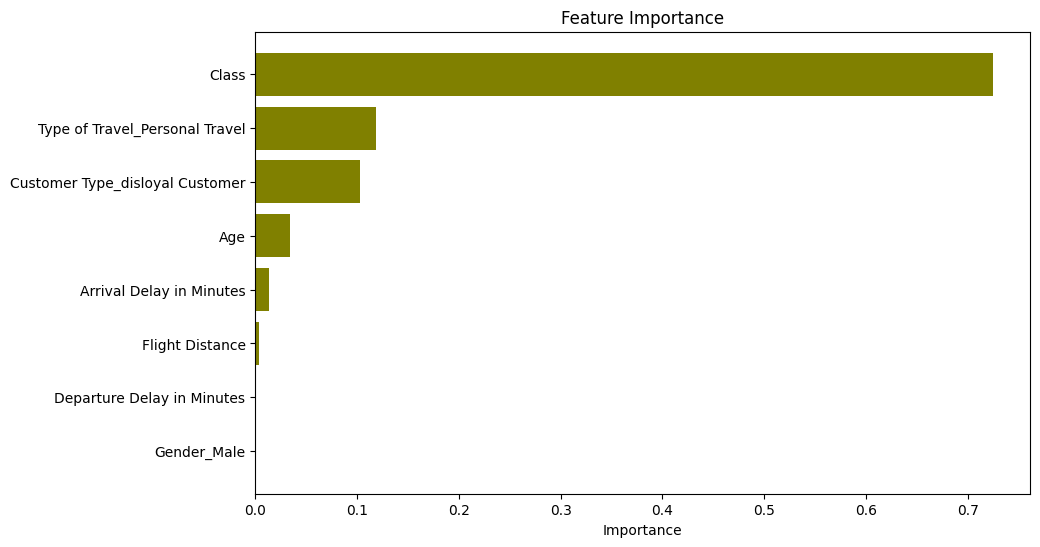

In [100]:
importance = best_xgb_grid.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})


feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)


plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='olive')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

Como podemos ver, la variable más importante termina siendo la Clase en la que viaja el usuario y el tipo de viaje que hace. Aquellos que viajan en primera tienden a estar mucho más satisfechos con la aerolinea que aquellos que viajan en economica. Esto va en línea con lo que vimos en los gráficos bivariados de la variable, el target medio de los usuarios que viajan en primera es casi del 70%.

In [101]:
print('Bivariado de la variable Clase en train: ')
display(df_train.groupby('Class').agg({'target':['count','mean']}))
print('\n')
print('Bivariado de la variable Clase en test: ')
display(df_test.groupby('Class').agg({'target':['count','mean']}))

Bivariado de la variable Clase en train: 


target          
       count      mean
Class                 
0.0    46716  0.186938
1.0     7539  0.244727
2.0    49649  0.694797



Bivariado de la variable Clase en test: 


target          
       count      mean
Class                 
0.0    11593  0.190632
1.0     1872  0.253205
2.0    12511  0.692990